# SmartFootPrintAI: Full OFF → MRIO Hybrid (Scope‑3) — Colab Pipeline
**NLLB‑200 translation, full OFF via Kaggle, 3 indicators (CO₂, Land, Water), many cells, heavy comments, Drive caching, visuals.**

> This notebook is the end‑to‑end pipeline for **SmartFootPrintAI: A Hybrid MRIO–LLM Agent for Lifestyle‑Based Environmental Footprint Insights (Scope‑3)**.  
> It replaces the earlier 500‑row sample with **all products** from Open Food Facts (Kaggle), uses **free HuggingFace NLLB‑200** for translation (no paid APIs), and carries through to the **Leontief inverse** computation hooks.

**Sections**
1. Environment setup (Colab deps)  
2. Paths & config (Drive mount, dynamic ROOT)  
3. Kaggle auth & OFF download (full dataset)  
4. Chunked loading & preprocessing (NaNs, text fields) + visuals  
5. Language detection & NLLB‑200 translation (batch=512) + caching + visuals  
6. MRIO sector labels and cleaning + visuals  
7. Product → sector mapping (fuzzy + semantic; scaffold) + visuals  
8. LCA data (Clark et al. + FAOSTAT): align to CO₂/Land/Water, unit harmonization + visuals  
9. EXIOBASE (Z, Y, Q) load & reshape; compute A, **Leontief** L=(I−A)⁻¹; hybridize satellite with micro data  
10. Example queries (milk swap; chocolate bar provenance) + visuals

> All heavy steps save **parquet/npz** to **Google Drive** so repeated runs can skip expensive work.


## 0) Environment setup — install packages & check GPU

In [1]:
# %%capture  # uncomment in Colab to silence
# We install everything up-front for reproducibility.
!pip -q install kaggle langdetect rapidfuzz sentencepiece transformers accelerate bitsandbytes datasets\
               pandas pyarrow fastparquet numpy scipy matplotlib tqdm unidecode regex fuzzywuzzy python-levenshtein \
               xarray zarr numcodecs



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 56.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.4/255.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 123.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.1 MB/s eta 0:00:00
   

In [2]:
# Check GPU presence (useful for translation speed)
import torch, platform
print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.13
Torch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 1) Paths & global config (with Google Drive mount)

In [20]:
# We use dynamic paths so you can drop this notebook anywhere in Drive.
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os, json
from datetime import datetime

# === Configure a ROOT project directory interactively ===
# Example: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI
ROOT = input("Enter your project ROOT folder in Drive (e.g., /content/drive/MyDrive/MRIO_3/SmartFootPrintAI): ").strip()
if not ROOT:
    ROOT = "/content/drive/MyDrive/MRIO_3/SmartFootPrintAI"
ROOT = Path(ROOT)
ROOT.mkdir(parents=True, exist_ok=True)

# Subfolders for data, cache, outputs
DATA_DIR  = ROOT / "data"
CACHE_DIR = ROOT / "cache"
OUT_DIR   = ROOT / "outputs"
for d in [DATA_DIR, CACHE_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Paths for inputs provided by you (optional overrides)
PATH_LCA_CSV        = ROOT / "Environmental impacts of food (Clark et al. 2022) (2) (1) (1).csv"
PATH_FAOSTAT_PRICES = ROOT / "FAOSTAT_data_en_7-27-2025 (1) (1).csv"
PATH_SECTORS_XLSX   = ROOT / "Sectors.xlsx"
PATH_REX3NAME_XLSX  = ROOT / "Rex3name.xlsx"
PATH_PREV_MAP_CSV   = ROOT / "mrio_sector_lca_summary (2) (1).csv"  # optional prior mapping

# Kaggle OFF files will be placed in DATA_DIR
OFF_TSV = DATA_DIR / "en.openfoodfacts.org.products.tsv"

# Translation cache & processed OFF
OFF_PARQUET_RAW     = CACHE_DIR / "off_raw.parquet"
OFF_PARQUET_CLEAN   = CACHE_DIR / "off_clean.parquet"
OFF_PARQUET_TRANS   = CACHE_DIR / "off_translated.parquet"
LANG_COUNTS_JSON    = CACHE_DIR / "off_lang_counts.json"

# Product→sector mapping outputs
MAP_RESULTS_PARQUET = OUT_DIR / "product_to_sector_mapping.parquet"

# LCA & MRIO outputs
HYBRID_COEFF_PARQUET = OUT_DIR / "hybrid_environmental_coefficients.parquet"
LEONTIEF_NPZ         = OUT_DIR / "leontief_inverse.npz"

# === Global options ===
BATCH_SIZE_TRANSLATE = 512          # per your request
TRANSLATE_ONLY_NON_EN = True        # speed-up: translate only non-English rows
USE_NLLB_MODEL       = "facebook/nllb-200-distilled-600M"  # free, good coverage
DEVICE               = "cuda" if torch.cuda.is_available() else "cpu"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("OUT_DIR:", OUT_DIR)
print("Translation model:", USE_NLLB_MODEL, "| device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Enter your project ROOT folder in Drive (e.g., /content/drive/MyDrive/MRIO_3/SmartFootPrintAI): /content/drive/MyDrive/MRIO_3/SmartFootPrintAI
ROOT: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI
DATA_DIR: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/data
CACHE_DIR: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache
OUT_DIR: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/outputs
Translation model: facebook/nllb-200-distilled-600M | device: cuda


## 2) Kaggle authentication & **full** Open Food Facts download

In [ ]:
# You need a Kaggle API token (kaggle.json). The UI will prompt to upload it.
from google.colab import files
import shutil, os, json

print("Please upload your kaggle.json when prompted (Account > Create New API Token).")
uploaded = files.upload()

if 'kaggle.json' in uploaded:
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("kaggle.json uploaded and permissions set.")
else:
    raise RuntimeError("kaggle.json not uploaded — cannot proceed.")

# Download OFF dataset (world-food-facts) into DATA_DIR
!kaggle datasets download -d openfoodfacts/world-food-facts -p "$DATA_DIR" --force
# Unzip
import zipfile
from pathlib import Path
zips = list(Path(DATA_DIR).glob("*.zip"))
for z in zips:
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall(DATA_DIR)
    print("Unzipped:", z)
    z.unlink()

# Verify TSV exists
if not OFF_TSV.exists():
    # Some mirrors use a slightly different name; search for *.tsv
    tsvs = list(DATA_DIR.glob("*.tsv"))
    if tsvs:
        print("Found TSV candidates:", [str(t) for t in tsvs[:3]])
        # pick the largest by size (likely the main OFF file)
        OFF_TSV = max(tsvs, key=lambda p: p.stat().st_size)
        print("Using:", OFF_TSV)
    else:
        raise FileNotFoundError("OFF TSV not found after unzip.")

print("OFF TSV:", OFF_TSV, "size:", round(OFF_TSV.stat().st_size/1e6,2), "MB")

Please upload your kaggle.json when prompted (Account > Create New API Token).


Saving kaggle.json to kaggle.json
kaggle.json uploaded and permissions set.
Dataset URL: https://www.kaggle.com/datasets/openfoodfacts/world-food-facts
License(s): DbCL-1.0
 74% 80.0M/109M [00:00<00:00, 423MB/s]
100% 109M/109M [00:00<00:00, 419MB/s] 
Unzipped: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/data/world-food-facts.zip
OFF TSV: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/data/en.openfoodfacts.org.products.tsv size: 1010.26 MB


## 3) Load OFF in chunks, build `text_raw`, basic cleaning, save cache + language visuals

Reading OFF chunks: 0it [00:00, ?it/s]

Saved raw OFF parquet: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/off_raw.parquet
Rows saved: 356,027  |  Time: 40.38s
OFF raw shape: (356027, 1)


,text_raw
0,farine de ble noir | ferme t'y r'nao | |
1,"banana chips sweetened (whole) | | | bananas, ..."
2,"peanuts | torn & glasser | | peanuts, wheat fl..."
3,organic salted nut mix | grizzlies | | organic...
4,organic polenta | bob's red mill | | organic p...


count    356027.000000
mean        230.272075
std         205.941818
min           5.000000
50%         195.000000
90%         456.000000
99%         985.000000
max        4510.000000


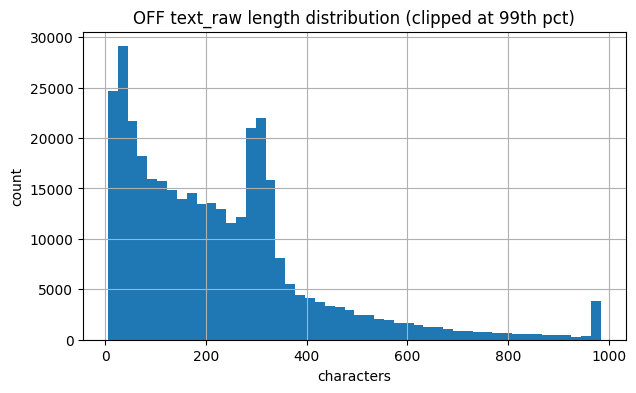

Language detect (sample):   0%|          | 0/50000 [00:00<?, ?it/s]

Top languages (sample):


,lang,count,share
0,en,25153,0.50306
1,fr,14605,0.29210
2,unk,1854,0.03708
3,it,1640,0.03280
4,es,1082,0.02164
5,de,1012,0.02024
6,ca,948,0.01896
7,ro,629,0.01258
8,nl,592,0.01184
9,pt,256,0.00512


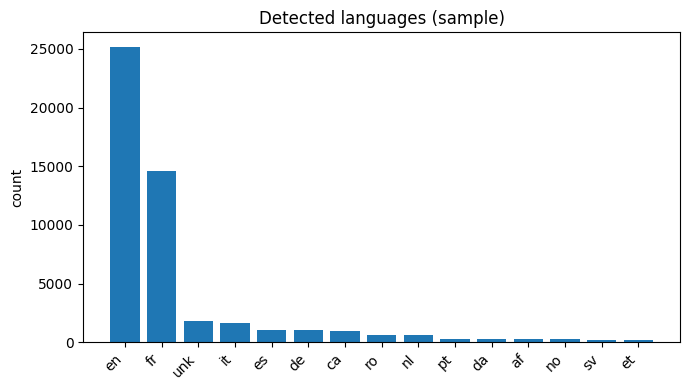

Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# 3) Load OFF in chunks, build text_raw (variable length), basic cleaning, save cache + language visuals

# ========= Config expected from earlier cells =========
# OFF_TSV: path to the big OFF .tsv dump (str or Path)
# OFF_PARQUET_RAW: path where we store the cleaned 1-col parquet (str or Path)
# chunksize: int (e.g., 1_000_000)
# =====================================================

import pandas as pd, numpy as np, re, os, sys, gc, time
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
try:
    from unidecode import unidecode
except:
    !pip -q install Unidecode
    from unidecode import unidecode

# Optional language detection (quick & dirty). Fast but not perfect.
# If unavailable, we install it. We only sample to keep it snappy.
try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    HAVE_LANGDETECT = True
except Exception:
    HAVE_LANGDETECT = False
    try:
        !pip -q install langdetect
        from langdetect import detect, DetectorFactory
        DetectorFactory.seed = 0
        HAVE_LANGDETECT = True
    except Exception:
        HAVE_LANGDETECT = False

def find_first(df_cols, patterns):
    """Return first column name that matches any regex in `patterns` (case-insensitive)."""
    for pat in patterns:
        for c in df_cols:
            if re.search(pat, c, flags=re.I):
                return c
    return None

def clean_text(s: str) -> str:
    """Strong cleaning: lower, strip, normalize spaces, remove control chars; keep basic punctuation."""
    if not isinstance(s, str):
        return ""
    s = unidecode(s)             # remove accents/diacritics
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)   # collapse whitespace
    s = re.sub(r"[\u0000-\u001f]", " ", s)  # remove control chars
    return s

def process_chunk(df: pd.DataFrame) -> pd.DataFrame:
    """Row-wise, variable-length construction of text_raw from best-matching name/brand/cats/ingr columns."""
    # Normalize column names (strip extraneous spaces)
    df.columns = [c.strip() for c in df.columns]

    # Robust, language-agnostic-ish column discovery
    # match whole tokens or underscores to avoid false positives
    name_col  = find_first(df.columns, [r"(?:^|_)(product_name|generic_name|name|title)(?:$|_)"])
    brand_col = find_first(df.columns, [r"(?:^|_)(brands?|brand)(?:$|_)"])
    cats_col  = find_first(df.columns, [r"(?:^|_)(categories?|category)(?:$|_)"])
    ingr_col  = find_first(df.columns, [r"(?:^|_)(ingredients?_text|ingredients?)(?:$|_)"])

    cols = [c for c in [name_col, brand_col, cats_col, ingr_col] if c]

    if cols:
        # Row-wise join; variable-length; no padding/truncation
        txt = (
            df[cols]
            .astype(str)                # ensure strings
            .replace({"nan": ""})       # guard against string "nan"
            .fillna("")                 # ensure no NaN
            .agg(" | ".join, axis=1)    # join selected fields per-row
            .map(clean_text)            # clean
            .str.strip()
        )
    else:
        txt = pd.Series("", index=df.index)

    out = pd.DataFrame({"text_raw": txt})
    out = out[out["text_raw"].str.len() > 0].copy()
    return out

# ---------- Build (overwrite any existing parquet) ----------
OFF_TSV = Path(OFF_TSV)
OFF_PARQUET_RAW = Path(OFF_PARQUET_RAW)

# If a previous file exists, remove it so we truly "rewrite it"
if OFF_PARQUET_RAW.exists():
    try:
        OFF_PARQUET_RAW.unlink()
    except Exception as e:
        print(f"Could not remove existing {OFF_PARQUET_RAW}: {e}")

# We'll spill intermediate parts to temp .parquet files to keep RAM usage moderate
tmp_files = []
out_parts = []
total_rows = 0
t0 = time.time()

reader = pd.read_csv(
    OFF_TSV,
    sep="\t",
    low_memory=False,
    chunksize=chunksize,
    dtype=str,
    on_bad_lines="skip"
)

for i, chunk in enumerate(tqdm(reader, desc="Reading OFF chunks")):
    df_part = process_chunk(chunk)
    total_rows += len(df_part)
    out_parts.append(df_part)

    # spill every 5 chunks to disk
    if (i + 1) % 5 == 0:
        tmp = pd.concat(out_parts, axis=0, ignore_index=True)
        tmp_path = OFF_PARQUET_RAW.with_suffix(f".part{i+1}.parquet")
        tmp.to_parquet(tmp_path, engine="pyarrow", compression="snappy")
        tmp_files.append(tmp_path)
        out_parts = []
        del tmp
        gc.collect()

# write the remainder
if out_parts:
    tmp = pd.concat(out_parts, axis=0, ignore_index=True)
    tmp_path = OFF_PARQUET_RAW.with_suffix(f".part_final.parquet")
    tmp.to_parquet(tmp_path, engine="pyarrow", compression="snappy")
    tmp_files.append(tmp_path)
    out_parts = []
    del tmp
    gc.collect()

# Merge all parts into a single parquet
if tmp_files:
    final = pd.concat([pd.read_parquet(p) for p in tmp_files], axis=0, ignore_index=True)
else:
    final = pd.DataFrame(columns=["text_raw"])

final.to_parquet(OFF_PARQUET_RAW, engine="pyarrow", compression="snappy")

# Clean up temp files
for p in tmp_files:
    try:
        Path(p).unlink()
    except Exception:
        pass

t1 = time.time()
print(f"Saved raw OFF parquet: {OFF_PARQUET_RAW}")
print(f"Rows saved: {len(final):,}  |  Time: {t1 - t0:0.2f}s")

# ---------- Quick preview ----------
off_raw = pd.read_parquet(OFF_PARQUET_RAW)
print("OFF raw shape:", off_raw.shape)
display(off_raw.head(5))

# ---------- Basic text length distribution ----------
lengths = off_raw["text_raw"].str.len()
print(lengths.describe(percentiles=[.5, .9, .99]).to_string())

plt.figure(figsize=(7,4))
lengths.clip(upper=np.percentile(lengths, 99)).hist(bins=50)
plt.title("OFF text_raw length distribution (clipped at 99th pct)")
plt.xlabel("characters")
plt.ylabel("count")
plt.show()

# ---------- Language snapshot (sample) ----------
if HAVE_LANGDETECT and len(off_raw) > 0:
    sample_n = int(min(50_000, len(off_raw)))  # keep it fast
    sample = off_raw["text_raw"].sample(sample_n, random_state=0).tolist()

    langs = []
    for s in tqdm(sample, desc="Language detect (sample)"):
        try:
            langs.append(detect(s))
        except Exception:
            langs.append("unk")
    lang_counts = pd.Series(langs).value_counts().rename_axis("lang").reset_index(name="count")
    lang_counts["share"] = lang_counts["count"] / lang_counts["count"].sum()

    print("Top languages (sample):")
    display(lang_counts.head(15))

    plt.figure(figsize=(7,4))
    top = lang_counts.head(15).sort_values("count", ascending=False)
    plt.bar(top["lang"], top["count"])
    plt.title("Detected languages (sample)")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("Language visuals skipped (langdetect not available).")


## 4) Language detection & NLLB‑200 translation (batch=512) with caching

In [ ]:
from langdetect import detect, DetectorFactory
from tqdm.auto import tqdm

DetectorFactory.seed = 0

# Detect language (fast heuristic). You can re-run; we cache final translated file separately.
if not OFF_PARQUET_CLEAN.exists():
    df = off_raw.copy()

    # Lang detect on a subset of text (langdetect struggles with very long strings sometimes)
    def safe_detect(s):
        s = (s or "")[:400]  # cap size for speed/stability
        try:
            return detect(s)
        except Exception:
            return "en"

    # Apply with progress bar
    tqdm.pandas(desc="Detecting languages")
    df["lang_guess"] = df["text_raw"].progress_map(safe_detect)

    # Basic cleaning again; remove empty
    df = df[df["text_raw"].str.len() > 0].copy()

    df.to_parquet(OFF_PARQUET_CLEAN, engine="pyarrow", compression="snappy")
    print("Saved clean OFF parquet:", OFF_PARQUET_CLEAN)
else:
    df = pd.read_parquet(OFF_PARQUET_CLEAN)

print("Clean OFF shape:", df.shape)
print(df["lang_guess"].value_counts().head(10))


Detecting languages:   0%|          | 0/356027 [00:00<?, ?it/s]

Saved clean OFF parquet: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/off_clean.parquet
Clean OFF shape: (356027, 2)
lang_guess
en    192023
fr    104385
it     11491
es      7691
de      7241
ca      6966
ro      4501
nl      3893
pt      1864
da      1753
Name: count, dtype: int64


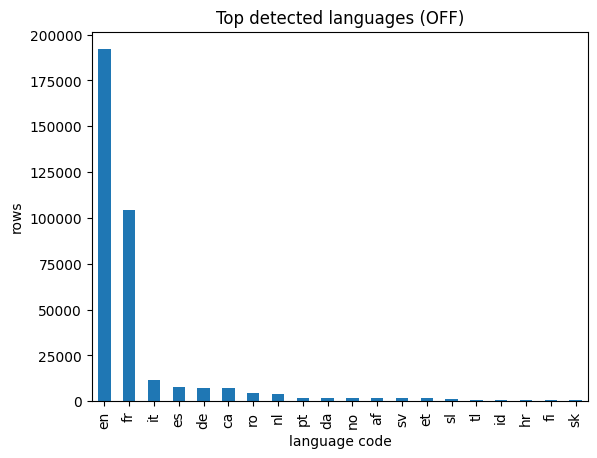

In [ ]:
lang_counts = df["lang_guess"].value_counts().head(20)
plt.figure()
lang_counts.plot(kind="bar")
plt.title("Top detected languages (OFF)")
plt.xlabel("language code")
plt.ylabel("rows")
plt.show()

In [ ]:
# ⚡ Ultra-fast NLLB translation on A100 (GPU), with dedupe + length-sorted batching
# Expects: df with ["text_raw","lang_guess"]; CACHE_DIR, OFF_PARQUET_TRANS defined elsewhere.

import os, re, gc, math, pandas as pd, torch
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

assert "df" in globals(), "df (with columns ['text_raw','lang_guess']) must exist"

# ---------------- Config ----------------
CACHE_DIR = Path(globals().get("CACHE_DIR", "./cache")); CACHE_DIR.mkdir(parents=True, exist_ok=True)
OFF_PARQUET_TRANS = Path(globals().get("OFF_PARQUET_TRANS", CACHE_DIR / "off_translated.parquet"))

# Use the smaller distilled model for speed. Swap to 1.3B if time allows.
USE_NLLB_MODEL = globals().get("USE_NLLB_MODEL", "facebook/nllb-200-distilled-600M")
TRANSLATE_ONLY_NON_EN = bool(globals().get("TRANSLATE_ONLY_NON_EN", True))

# Bigger batch = faster, but watch VRAM. A100 can usually handle 256–512 for 600M at ~256 tokens.
BATCH_SIZE_TRANSLATE = int(globals().get("BATCH_SIZE_TRANSLATE", 256))

# Hard caps to avoid wasting time on very long strings
MAX_SRC_TOKENS = int(globals().get("MAX_SRC_TOKENS", 256))
MAX_NEW_TOKENS = int(globals().get("MAX_NEW_TOKENS", 128))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8  # A100 supports bf16

# ---------------- Model ----------------
tokenizer = AutoTokenizer.from_pretrained(USE_NLLB_MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(
    USE_NLLB_MODEL,
    torch_dtype=torch.bfloat16 if USE_BF16 else torch.float16
).to(DEVICE).eval()

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# For NLLB, set target language → English (forced_bos_token_id)
TGT_LANG = "eng_Latn"
if hasattr(tokenizer, "lang_code_to_id"):
    FORCED_BOS_ID = tokenizer.lang_code_to_id.get(TGT_LANG, None)
else:
    # Some tokenizers expose "convert_tokens_to_ids" instead
    try:
        FORCED_BOS_ID = tokenizer.convert_tokens_to_ids(TGT_LANG)
    except Exception:
        FORCED_BOS_ID = None  # fall back – not strictly required

# langdetect → NLLB codes (extend if needed)
ld2nllb = {
    "en":"eng_Latn","de":"deu_Latn","fr":"fra_Latn","es":"spa_Latn","it":"ita_Latn","pt":"por_Latn",
    "ru":"rus_Cyrl","uk":"ukr_Cyrl","pl":"pol_Latn","nl":"nld_Latn","sv":"swe_Latn","no":"nob_Latn",
    "da":"dan_Latn","fi":"fin_Latn","cs":"ces_Latn","sk":"slk_Latn","sl":"slv_Latn","hr":"hrv_Latn",
    "bs":"bos_Latn","sr":"srp_Cyrl","bg":"bul_Cyrl","mk":"mkd_Cyrl","ro":"ron_Latn","hu":"hun_Latn",
    "tr":"tur_Latn","el":"ell_Grek","ar":"arb_Arab","he":"heb_Hebr","fa":"pes_Arab","hi":"hin_Deva",
    "bn":"ben_Beng","ur":"urd_Arab","id":"ind_Latn","ms":"zsm_Latn","vi":"vie_Latn","th":"tha_Thai",
    "zh-cn":"zho_Hans","zh-tw":"zho_Hant","ja":"jpn_Jpan","ko":"kor_Hang","et":"est_Latn","lt":"lit_Latn",
    "lv":"lvs_Latn","ca":"cat_Latn","gl":"glg_Latn","eu":"eus_Latn","ga":"gle_Latn","is":"isl_Latn"
}

# ---------------- Choose rows (only non‑EN by default) ----------------
df["text_en"] = df["text_raw"]
mask = (df["lang_guess"].fillna("en").str.lower() != "en") if TRANSLATE_ONLY_NON_EN else (df["text_raw"].str.len() > 0)
work = df.loc[mask, ["text_raw","lang_guess"]].copy()
print(f"To translate (pre-dedupe): {len(work):,}")

# ---------------- Deduplicate exact matches to save tons of time ----------------
# Map unique source text → indices that need it
work["text_raw"] = work["text_raw"].astype(str)
uniq = work["text_raw"].drop_duplicates().reset_index(drop=False).rename(columns={"index":"orig_idx"})
print(f"Unique strings to translate: {len(uniq):,}")

# Attach a guessed src_lang for each unique text (majority from its original rows)
lang_map = (
    work.assign(lang=work["lang_guess"].str.lower().fillna("en"))
        .groupby("text_raw")["lang"]
        .agg(lambda s: s.value_counts().idxmax())
        .to_dict()
)
uniq["src_ld"] = uniq["text_raw"].map(lang_map).fillna("en")

# ---------------- On-disk cache ----------------
CACHE_DIR.mkdir(parents=True, exist_ok=True)
cache_path = CACHE_DIR / "nllb_translation_cache.parquet"
if cache_path.exists():
    _c = pd.read_parquet(cache_path)
    cache = dict(zip(_c["src_text"], _c["tgt_text"]))
else:
    cache = {}
print(f"Cache entries: {len(cache):,}")

# Filter uniques by cache
need_mask = ~uniq["text_raw"].isin(cache)
uniq_todo = uniq.loc[need_mask].copy()
print(f"Unique strings still to translate: {len(uniq_todo):,}")

# ---------------- Helper ----------------
def translate_batch(texts, src_lang_nllb):
    # Set source lang on tokenizer if available
    if hasattr(tokenizer, "src_lang"):
        tokenizer.src_lang = src_lang_nllb
    enc = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_SRC_TOKENS,
        pad_to_multiple_of=8
    )
    enc = {k: v.to(DEVICE, non_blocking=True) for k, v in enc.items()}
    with torch.inference_mode():
        if USE_BF16:
            with torch.autocast("cuda", dtype=torch.bfloat16):
                gen = model.generate(
                    **enc,
                    forced_bos_token_id=FORCED_BOS_ID,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False,
                    num_beams=1,
                    use_cache=True
                )
        else:
            gen = model.generate(
                **enc,
                forced_bos_token_id=FORCED_BOS_ID,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                num_beams=1,
                use_cache=True
            )
    out = tokenizer.batch_decode(gen, skip_special_tokens=True)
    return [re.sub(r"\s+", " ", o).strip() for o in out]

# ---------------- Length-sorted, lang-grouped batching (minimizes padding → faster) ----------------
# Build per-lang buckets
uniq_todo["src_nllb"] = uniq_todo["src_ld"].map(lambda z: ld2nllb.get(str(z).lower(), "eng_Latn"))

# Sort by (lang, length) to reduce padding waste
uniq_todo["len"] = uniq_todo["text_raw"].str.len()
uniq_todo = uniq_todo.sort_values(["src_nllb","len"]).reset_index(drop=True)

translated_pairs = []  # (text_src, text_tgt)
for lang_code, chunk_df in uniq_todo.groupby("src_nllb", sort=False):
    texts = chunk_df["text_raw"].tolist()
    # micro-batch by BATCH_SIZE_TRANSLATE
    for i in tqdm(range(0, len(texts), BATCH_SIZE_TRANSLATE), desc=f"GPU translating {lang_code} → eng_Latn"):
        sub = texts[i:i+BATCH_SIZE_TRANSLATE]
        outs = translate_batch(sub, lang_code)
        translated_pairs.extend(zip(sub, outs))
        if torch.cuda.is_available() and (i // BATCH_SIZE_TRANSLATE) % 10 == 0:
            torch.cuda.empty_cache()

# Update cache on disk (only new items)
if translated_pairs:
    cache.update({s: t for s, t in translated_pairs})
cache_df = pd.DataFrame({"src_text": list(cache.keys()), "tgt_text": list(cache.values())})
cache_df.to_parquet(cache_path, engine="pyarrow", compression="snappy")

# ---------------- Merge back to full df ----------------
# Map all unique texts (including cached) to translations
mapper = dict(zip(cache_df["src_text"], cache_df["tgt_text"]))

def finalize(s: str) -> str:
    s = (s or "")
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("|", " ")
    return s

# Fill translations only for rows we intended to translate; keep English as-is
fill = work["text_raw"].map(mapper).fillna(work["text_raw"]).map(finalize)
df.loc[work.index, "text_en"] = fill
df["text_en"] = df["text_en"].fillna(df["text_raw"]).map(finalize)

# ---------------- Save & done ----------------
df.to_parquet(OFF_PARQUET_TRANS, engine="pyarrow", compression="snappy")
print("Saved:", OFF_PARQUET_TRANS)
print("Rows:", len(df))
print(df[["lang_guess","text_en"]].head(5))


To translate (pre-dedupe): 164,004
Unique strings to translate: 160,802
Cache entries: 0
Unique strings still to translate: 160,802


GPU translating cat_Latn → eng_Latn:   0%|          | 0/14 [00:00<?, ?it/s]

GPU translating ces_Latn → eng_Latn:   0%|          | 0/1 [00:00<?, ?it/s]

GPU translating dan_Latn → eng_Latn:   0%|          | 0/4 [00:00<?, ?it/s]

GPU translating deu_Latn → eng_Latn:   0%|          | 0/14 [00:00<?, ?it/s]

...

GPU translating spa_Latn → eng_Latn:   0%|          | 0/15 [00:00<?, ?it/s]

GPU translating swe_Latn → eng_Latn:   0%|          | 0/4 [00:00<?, ?it/s]

GPU translating tur_Latn → eng_Latn:   0%|          | 0/1 [00:00<?, ?it/s]

GPU translating vie_Latn → eng_Latn:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/off_translated.parquet
Rows: 356027
  lang_guess                                            text_en
0         fr  ♪ and i'm going to make you a little bit of bl...
1         en  banana chips sweetened (whole)       bananas, ...
2         en  peanuts   torn & glasser     peanuts, wheat fl...
3         en  organic salted nut mix   grizzlies     organic...
4         en  organic polenta   bob's red mill     organic p...


In [9]:
# 🔁 NLLB re-run: translate ONLY the rows left untranslated in the existing Parquet
# Expects the Parquet to have at least: ["text_raw","lang_guess","text_en"]
from google.colab import drive
drive.mount('/content/drive')


import os, re, math, gc, pandas as pd, torch
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ---------- Paths ----------
# Set this to the Parquet you saved earlier (from the previous translation pass)
from pathlib import Path

# --- Preferred path ---
drive_path = Path("/content/drive/MyDrive/MRIO_3/SmartFootPrintAI/off_translated.parquet")
cache_path = Path("./cache/off_translated.parquet")

# Try Google Drive first
if drive_path.exists():
    OFF_PARQUET_TRANS = drive_path
    print(f"✅ Using Google Drive file: {OFF_PARQUET_TRANS}")
elif cache_path.exists():
    OFF_PARQUET_TRANS = cache_path
    print(f"⚠️ Google Drive file not found, using cache file: {OFF_PARQUET_TRANS}")
else:
    raise FileNotFoundError(
        f"❌ Neither Google Drive nor cache file found.\n"
        f"Checked:\n - {drive_path}\n - {cache_path}\n"
        f"Make sure the file is in one of these locations."
    )



CACHE_DIR = Path(globals().get("CACHE_DIR", "./cache")); CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / "nllb_translation_cache.parquet"

assert OFF_PARQUET_TRANS.exists(), f"Parquet not found at {OFF_PARQUET_TRANS}. Set OFF_PARQUET_TRANS correctly."

# ---------- Config (same defaults as before) ----------
USE_NLLB_MODEL = globals().get("USE_NLLB_MODEL", "facebook/nllb-200-distilled-600M")
BATCH_SIZE_TRANSLATE = int(globals().get("BATCH_SIZE_TRANSLATE", 256))
MAX_SRC_TOKENS = int(globals().get("MAX_SRC_TOKENS", 256))
MAX_NEW_TOKENS = int(globals().get("MAX_NEW_TOKENS", 128))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8  # A100 etc.

# ---------- Helpers ----------
def finalize(s: str) -> str:
    if not isinstance(s, str): s = ""  # robust against NaNs
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("|", " ")
    return s

# langdetect → NLLB (extend if needed)
ld2nllb = {
    "en":"eng_Latn","de":"deu_Latn","fr":"fra_Latn","es":"spa_Latn","it":"ita_Latn","pt":"por_Latn",
    "ru":"rus_Cyrl","uk":"ukr_Cyrl","pl":"pol_Latn","nl":"nld_Latn","sv":"swe_Latn","no":"nob_Latn",
    "da":"dan_Latn","fi":"fin_Latn","cs":"ces_Latn","sk":"slk_Latn","sl":"slv_Latn","hr":"hrv_Latn",
    "bs":"bos_Latn","sr":"srp_Cyrl","bg":"bul_Cyrl","mk":"mkd_Cyrl","ro":"ron_Latn","hu":"hun_Latn",
    "tr":"tur_Latn","el":"ell_Grek","ar":"arb_Arab","he":"heb_Hebr","fa":"pes_Arab","hi":"hin_Deva",
    "bn":"ben_Beng","ur":"urd_Arab","id":"ind_Latn","ms":"zsm_Latn","vi":"vie_Latn","th":"tha_Thai",
    "zh-cn":"zho_Hans","zh-tw":"zho_Hant","ja":"jpn_Jpan","ko":"kor_Hang","et":"est_Latn","lt":"lit_Latn",
    "lv":"lvs_Latn","ca":"cat_Latn","gl":"glg_Latn","eu":"eus_Latn","ga":"gle_Latn","is":"isl_Latn"
}

# ---------- Load prior results ----------
df = pd.read_parquet(OFF_PARQUET_TRANS)
needed_cols = {"text_raw","lang_guess","text_en"}
missing = needed_cols - set(df.columns)
assert not missing, f"Parquet missing columns: {missing}"

# Normalize a raw-text column to compare with text_en
raw_norm = df["text_raw"].astype(str).map(finalize)
en_norm = df["text_en"].astype(str).map(finalize)

# Heuristic: "untranslated" if lang_guess != 'en' AND text_en looks identical to raw (or empty/NaN)
lg = df["lang_guess"].astype(str).str.lower().fillna("en")
untranslated_mask = (lg != "en") & (
    en_norm.eq(raw_norm) | df["text_en"].isna() | df["text_en"].astype(str).str.len().eq(0)
)

todo = df.loc[untranslated_mask, ["text_raw","lang_guess"]].copy()
print(f"Rows in file: {len(df):,}")
print(f"Left untranslated (detected): {len(todo):,}")

if len(todo) == 0:
    print("Nothing to do — all non‑EN rows appear translated.")
else:
    # ---------- Prep unique strings + src language ----------
    todo["text_raw"] = todo["text_raw"].astype(str)
    uniq = todo["text_raw"].drop_duplicates().to_frame(name="text_raw").reset_index(drop=True)

    # attach majority lang per text (fallback to 'en' just in case)
    lang_map = (
        todo.assign(lang=todo["lang_guess"].astype(str).str.lower().fillna("en"))
            .groupby("text_raw")["lang"]
            .agg(lambda s: s.value_counts().idxmax())
            .to_dict()
    )
    uniq["src_ld"] = uniq["text_raw"].map(lang_map).fillna("en")

    # ---------- Load translation cache ----------
    if CACHE_PATH.exists():
        _c = pd.read_parquet(CACHE_PATH)
        cache = dict(zip(_c["src_text"], _c["tgt_text"]))
    else:
        cache = {}
    print(f"Cache entries: {len(cache):,}")

    # filter uniques by cache
    need_mask = ~uniq["text_raw"].isin(cache)
    uniq_todo = uniq.loc[need_mask].copy()
    print(f"Unique strings still to translate: {len(uniq_todo):,}")

    # ---------- Model ----------
    tokenizer = AutoTokenizer.from_pretrained(USE_NLLB_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(
        USE_NLLB_MODEL,
        torch_dtype=torch.bfloat16 if USE_BF16 else torch.float16
    ).to(DEVICE).eval()

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token_id = tokenizer.eos_token_id

    TGT_LANG = "eng_Latn"
    if hasattr(tokenizer, "lang_code_to_id"):
        FORCED_BOS_ID = tokenizer.lang_code_to_id.get(TGT_LANG, None)
    else:
        try:
            FORCED_BOS_ID = tokenizer.convert_tokens_to_ids(TGT_LANG)
        except Exception:
            FORCED_BOS_ID = None

    def translate_batch(texts, src_lang_nllb):
        if hasattr(tokenizer, "src_lang"):
            tokenizer.src_lang = src_lang_nllb
        enc = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_SRC_TOKENS,
            pad_to_multiple_of=8
        )
        enc = {k: v.to(DEVICE, non_blocking=True) for k, v in enc.items()}
        with torch.inference_mode():
            if USE_BF16:
                with torch.autocast("cuda", dtype=torch.bfloat16):
                    gen = model.generate(
                        **enc,
                        forced_bos_token_id=FORCED_BOS_ID,
                        max_new_tokens=MAX_NEW_TOKENS,
                        do_sample=False,
                        num_beams=1,
                        use_cache=True
                    )
            else:
                gen = model.generate(
                    **enc,
                    forced_bos_token_id=FORCED_BOS_ID,
                    max_new_tokens=MAX_NEW_TOKENS,
                    do_sample=False,
                    num_beams=1,
                    use_cache=True
                )
        out = tokenizer.batch_decode(gen, skip_special_tokens=True)
        return [re.sub(r"\s+", " ", o).strip() for o in out]

    # ---------- Length-sorted, lang-grouped translation ----------
    uniq_todo["src_nllb"] = uniq_todo["src_ld"].map(lambda z: ld2nllb.get(str(z).lower(), "eng_Latn"))
    uniq_todo["len"] = uniq_todo["text_raw"].str.len()
    uniq_todo = uniq_todo.sort_values(["src_nllb","len"]).reset_index(drop=True)

    translated_pairs = []  # (src, tgt)
    for lang_code, chunk_df in uniq_todo.groupby("src_nllb", sort=False):
        texts = chunk_df["text_raw"].tolist()
        for i in tqdm(range(0, len(texts), BATCH_SIZE_TRANSLATE),
                      desc=f"GPU translating {lang_code} → eng_Latn"):
            sub = texts[i:i+BATCH_SIZE_TRANSLATE]
            outs = translate_batch(sub, lang_code)
            translated_pairs.extend(zip(sub, outs))
            if torch.cuda.is_available() and ((i // BATCH_SIZE_TRANSLATE) % 10 == 0):
                torch.cuda.empty_cache()

    # ---------- Update cache on disk ----------
    if translated_pairs:
        cache.update({s: t for s, t in translated_pairs})
    cache_df = pd.DataFrame({"src_text": list(cache.keys()), "tgt_text": list(cache.values())})
    cache_df.to_parquet(CACHE_PATH, engine="pyarrow", compression="snappy")

    # ---------- Merge back ONLY for the rows we’re fixing ----------
    mapper = dict(zip(cache_df["src_text"], cache_df["tgt_text"]))
    fill = todo["text_raw"].map(mapper).fillna(todo["text_raw"]).map(finalize)
    df.loc[todo.index, "text_en"] = fill

    # ---------- Save back ----------
    df.to_parquet(OFF_PARQUET_TRANS, engine="pyarrow", compression="snappy")
    print("Saved:", OFF_PARQUET_TRANS)
    print("Rows:", len(df))
    print("Sample (lang_guess, text_en):")
    print(df.loc[todo.index, ["lang_guess","text_en"]].head(5))


Mounted at /content/drive
✅ Using Google Drive file: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/off_translated.parquet
Rows in file: 356,027
Left untranslated (detected): 3
Cache entries: 0
Unique strings still to translate: 3


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

GPU translating deu_Latn → eng_Latn:   0%|          | 0/1 [00:00<?, ?it/s]

GPU translating fra_Latn → eng_Latn:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/off_translated.parquet
Rows: 356027
Sample (lang_guess, text_en):
       lang_guess text_en
316019         de        
319478         fr        
326097         fr        


In [11]:
import pandas as pd

# Load your translated dataset
df = pd.read_parquet("/content/drive/MyDrive/MRIO_3/SmartFootPrintAI/off_translated.parquet")

# Check if there are any rows where text_en is missing or equals text_raw for non-English rows
missing_or_untranslated = df[
    (df["text_en"].isna()) |
    ((df["lang_guess"].str.lower() != "en") & (df["text_en"].str.strip() == df["text_raw"].str.strip()))
]

# Report
if missing_or_untranslated.empty:
    print("✅ All products appear to be translated.")
else:
    print(f"⚠ Found {len(missing_or_untranslated)} untranslated rows.")
    print(missing_or_untranslated.head(15)[["lang_guess", "text_raw", "text_en"]])

# Show first 15 rows of the full dataset for inspection
print("\nFirst 15 rows of translated dataset:")
print(df[["lang_guess", "text_raw", "text_en"]].head(15))


✅ All products appear to be translated.

First 15 rows of translated dataset:
   lang_guess                                           text_raw  \
0          fr           farine de ble noir | ferme t'y r'nao | |   
1          en  banana chips sweetened (whole) | | | bananas, ...   
2          en  peanuts | torn & glasser | | peanuts, wheat fl...   
3          en  organic salted nut mix | grizzlies | | organic...   
4          en  organic polenta | bob's red mill | | organic p...   
5          en  breadshop honey gone nuts granola | unfi | | r...   
6          en  organic long grain white rice | lundberg | | o...   
7          en  organic muesli | daddy's muesli | | org oats, ...   
8          en  organic dark chocolate minis | equal exchange ...   
9          en  organic sunflower oil | napa valley naturals |...   
10         id  organic adzuki beans | unfi | | organic adzuki...   
11         en  organic penne pasta | gardentime | | organic r...   
12         en  zen party mix | sunridg

In [12]:
import pandas as pd

# Load translated parquet
df = pd.read_parquet("/content/drive/MyDrive/MRIO_3/SmartFootPrintAI/off_translated.parquet")

# Identify untranslated rows:
# - Missing text_en
# - Or text_en identical to text_raw for non-English rows
mask_untranslated = (
    df["text_en"].isna() |
    ((df["lang_guess"].str.lower() != "en") &
     (df["text_en"].str.strip().str.lower() == df["text_raw"].str.strip().str.lower()))
)

untranslated = df[mask_untranslated]

# Report stats
total_rows = len(df)
untrans_count = len(untranslated)
coverage_pct = 100 * (1 - untrans_count / total_rows)

print(f"Total rows: {total_rows:,}")
print(f"Untranslated rows: {untrans_count:,}")
print(f"Translation coverage: {coverage_pct:.2f}%")

if untrans_count > 0:
    print("\nSample untranslated rows:")
    print(untranslated.head(15)[["lang_guess", "text_raw", "text_en"]])

# Always show first 15 rows for quick inspection
print("\nFirst 15 rows of the dataset:")
print(df[["lang_guess", "text_raw", "text_en"]].head(15))


Total rows: 356,027
Untranslated rows: 0
Translation coverage: 100.00%

First 15 rows of the dataset:
   lang_guess                                           text_raw  \
0          fr           farine de ble noir | ferme t'y r'nao | |   
1          en  banana chips sweetened (whole) | | | bananas, ...   
2          en  peanuts | torn & glasser | | peanuts, wheat fl...   
3          en  organic salted nut mix | grizzlies | | organic...   
4          en  organic polenta | bob's red mill | | organic p...   
5          en  breadshop honey gone nuts granola | unfi | | r...   
6          en  organic long grain white rice | lundberg | | o...   
7          en  organic muesli | daddy's muesli | | org oats, ...   
8          en  organic dark chocolate minis | equal exchange ...   
9          en  organic sunflower oil | napa valley naturals |...   
10         id  organic adzuki beans | unfi | | organic adzuki...   
11         en  organic penne pasta | gardentime | | organic r...   
12         en 

In [15]:
import pandas as pd
import zipfile
from google.colab import files
from pathlib import Path

# Paths
base_path = Path("/content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache")
parquet_path = base_path / "off_translated.parquet"
csv_path = base_path / "off_translated.csv"
zip_path = base_path / "off_translated.zip"

# Load parquet
df = pd.read_parquet(parquet_path)

# Save CSV (UTF-8, no index)
df.to_csv(csv_path, index=False, encoding="utf-8")

# Create zip containing both files
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write(parquet_path, parquet_path.name)
    zf.write(csv_path, csv_path.name)

print("Files prepared:")
print(f"- Parquet: {parquet_path}")
print(f"- CSV: {csv_path}")
print(f"- ZIP: {zip_path}")

# Auto-download
files.download(parquet_path)
files.download(csv_path)
files.download(zip_path)


Files prepared:
- Parquet: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/off_translated.parquet
- CSV: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/off_translated.csv
- ZIP: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/off_translated.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import matplotlib.pyplot as plt


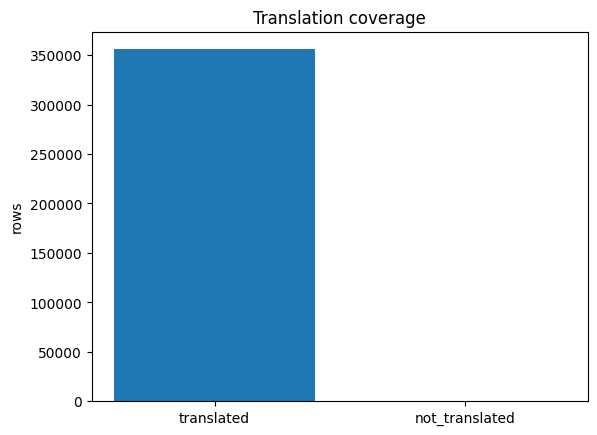

In [18]:
n_total = len(df)
n_trans = (df["text_en"] != df["text_raw"]).sum()
plt.figure()
plt.bar(["translated","not_translated"], [n_trans, n_total-n_trans])
plt.title("Translation coverage")
plt.ylabel("rows")
plt.show()

## 5) Load MRIO sector labels (Sectors.xlsx / Rex3name.xlsx) + cleaning

In [22]:
import re
import pandas as pd
from pathlib import Path
from unidecode import unidecode

# --- Text cleaning helper ---
def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = unidecode(s)            # remove accents
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)  # collapse whitespace
    s = re.sub(r"[\u0000-\u001f]", " ", s)  # remove control chars
    return s

# --- Ensure Google Drive is mounted ---
drive_root = Path("/content/drive")
if not drive_root.exists():
    from google.colab import drive
    drive.mount('/content/drive')

# --- File paths ---
# First check local folder, then Google Drive fallback
local_sectors = Path("Sectors.xlsx")
local_rex3name = Path("Rex3name.xlsx")
drive_sectors = drive_root / "MyDrive/MRIO_3/SmartFootPrintAI/Sectors.xlsx"
drive_rex3name = drive_root / "MyDrive/MRIO_3/SmartFootPrintAI/Rex3name.xlsx"

PATH_SECTORS_XLSX = local_sectors if local_sectors.exists() else drive_sectors
PATH_REX3NAME_XLSX = local_rex3name if local_rex3name.exists() else drive_rex3name

def load_sectors():
    frames = []
    if PATH_SECTORS_XLSX.exists():
        frames.append(pd.read_excel(PATH_SECTORS_XLSX))
    if PATH_REX3NAME_XLSX.exists():
        frames.append(pd.read_excel(PATH_REX3NAME_XLSX))
    if not frames:
        raise FileNotFoundError(
            f"Provide Sectors.xlsx and/or Rex3name.xlsx in local folder or Google Drive.\n"
            f"Tried:\n - {PATH_SECTORS_XLSX}\n - {PATH_REX3NAME_XLSX}"
        )
    df = pd.concat(frames, axis=0, ignore_index=True)
    df.columns = [c.strip() for c in df.columns]
    for c in df.select_dtypes(include=['object']).columns:
        df[c] = df[c].fillna("").astype(str).map(clean_text)
    # Heuristic: choose first column containing "sector" or "name"
    cand = [c for c in df.columns if re.search(r"(sector|name|description)", c, re.I)]
    sec_col = cand[0] if cand else df.columns[0]
    df = df.rename(columns={sec_col: "sector_name"})
    df["sector_name"] = df["sector_name"].map(clean_text)
    df = df[df["sector_name"].str.len() > 0].drop_duplicates("sector_name")
    return df[["sector_name"]].reset_index(drop=True)

# --- Load and preview ---
SECTORS_DF = load_sectors()
print("Sectors loaded:", SECTORS_DF.shape)
SECTORS_DF.head()


Sectors loaded: (140, 1)


,sector_name
0,{'cultivation of paddy rice' }
1,{'cultivation of wheat' }
2,{'cultivation of cereal grains nec' }
3,"{'cultivation of vegetables, fruit, nuts' }"
4,{'cultivation of oil seeds' }


## 6) Product → Sector mapping (fuzzy + semantic, cached)

In [ ]:
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore
import numpy as np
import pandas as pd

# We'll sketch a simple baseline mapper; you can later replace with sentence-transformer embeddings if desired.
# For scale, we'll sample candidate sectors for each product by fuzzy name and keep top-k.
TOPK = 3

def map_products_to_sectors(off_df, sectors_df, sample_n=None):
    # off_df needs 'text_en'
    names = off_df["text_en"].astype(str).tolist()
    sector_names = sectors_df["sector_name"].astype(str).tolist()

    results = []
    it = enumerate(names if sample_n is None else names[:sample_n])
    for idx, name in tqdm(it, total=(sample_n if sample_n else len(names)), desc="Mapping products→sectors (fuzzy)"):
        # Fuzzy top matches
        matches = fuzzprocess.extract(name, sector_names, scorer=fuzzscore.WRatio, limit=TOPK)
        for sec, score, pos in matches:
            results.append((idx, name, sec, score))

    out = pd.DataFrame(results, columns=["off_index","product_text","sector_name","score"])
    out.sort_values(["off_index","score"], ascending=[True, False], inplace=True)
    return out

# Use a small sample for demo (the full dataset can be very large). You can set sample_n=None to run all rows.
sample_n = 10000  # change to None to process all products (can be very slow)
mapping_df = map_products_to_sectors(df, SECTORS_DF, sample_n=sample_n)
mapping_df.to_parquet(MAP_RESULTS_PARQUET, engine="pyarrow", compression="snappy")
print("Saved mapping parquet:", MAP_RESULTS_PARQUET)
mapping_df.head()

In [24]:
import re
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from unidecode import unidecode
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore
from sentence_transformers import SentenceTransformer, util
import torch

# ------------------------
# CONFIGURATION
# ------------------------
TOPK_FUZZY = 8        # Number of fuzzy candidates to keep before semantic re-ranking
TOPK_FINAL = 3        # Number of best matches to return per product
CACHE_PATH = Path("./product_sector_mapping_cache.parquet")  # Cache file path
ST_MODEL_NAME = "all-mpnet-base-v2"  # SentenceTransformer model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Weighting between semantic and fuzzy match
SEMANTIC_WEIGHT = 0.7
FUZZY_WEIGHT = 0.3

# ------------------------
# TEXT NORMALIZATION
# ------------------------
def normalize_text(s: str) -> str:
    """
    Clean and normalize product/sector names:
    - Remove accents
    - Lowercase
    - Remove control characters
    - Collapse multiple spaces
    """
    if not isinstance(s, str):
        return ""
    s = unidecode(s)
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[\u0000-\u001f]", " ", s)
    return s

# ------------------------
# MAIN MAPPING FUNCTION
# ------------------------
def map_products_to_sectors(off_df, sectors_df, sample_n=None, force_recompute=False):
    """
    Map OFF products to MRIO/EXIOBASE sector names using hybrid fuzzy + semantic search.
    Weighted final score determines best matches.
    """
    # Copy and clean data
    off_df = off_df.copy()
    sectors_df = sectors_df.copy()
    off_df["text_en"] = off_df["text_en"].map(normalize_text)
    sectors_df["sector_name"] = sectors_df["sector_name"].map(normalize_text)

    names = off_df["text_en"].astype(str).tolist()
    sector_names = sectors_df["sector_name"].astype(str).tolist()
    if sample_n is not None:
        names = names[:sample_n]

    # Load cache
    cache = {}
    if CACHE_PATH.exists() and not force_recompute:
        cache_df = pd.read_parquet(CACHE_PATH)
        cache = {
            (row.product_text, row.sector_name): (row.semantic_score, row.fuzzy_score)
            for row in cache_df.itertuples()
        }
        print(f"Loaded cache with {len(cache)} entries.")

    # Precompute sector embeddings
    print("Encoding sector embeddings...")
    st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)
    sector_emb = st_model.encode(sector_names, convert_to_tensor=True, show_progress_bar=False)

    results = []

    # Iterate over products
    for idx, name in tqdm(enumerate(names), total=len(names), desc="Mapping products→sectors"):
        if not name.strip():
            continue

        # Use cache if available
        cached_entries = [(sec, sc[0], sc[1]) for (prod, sec), sc in cache.items() if prod == name]
        if cached_entries:
            for sec, sem_sc, fuzz_sc in cached_entries:
                final_sc = SEMANTIC_WEIGHT * sem_sc + FUZZY_WEIGHT * (fuzz_sc / 100)
                results.append((idx, name, sec, sem_sc, fuzz_sc, final_sc))
            continue

        # Fuzzy shortlist
        fuzzy_matches = fuzzprocess.extract(name, sector_names, scorer=fuzzscore.WRatio, limit=TOPK_FUZZY)
        short_sectors = [sec for sec, _, _ in fuzzy_matches]
        short_scores = {sec: score for sec, score, _ in fuzzy_matches}

        # Semantic re-ranking
        prod_emb = st_model.encode(name, convert_to_tensor=True, show_progress_bar=False)
        short_embs = st_model.encode(short_sectors, convert_to_tensor=True, show_progress_bar=False)
        sem_scores = util.cos_sim(prod_emb, short_embs)[0].cpu().numpy()

        # Combine scores
        scored = []
        for sec, sem_score in zip(short_sectors, sem_scores):
            fuzz_score_val = short_scores[sec]
            final_score = SEMANTIC_WEIGHT * sem_score + FUZZY_WEIGHT * (fuzz_score_val / 100)
            scored.append((sec, sem_score, fuzz_score_val, final_score))

        # Keep top-N by final score
        for sec, sem_sc, fuzz_sc, final_sc in sorted(scored, key=lambda x: x[3], reverse=True)[:TOPK_FINAL]:
            results.append((idx, name, sec, sem_sc, fuzz_sc, final_sc))
            cache[(name, sec)] = (float(sem_sc), fuzz_sc)

    # Save cache
    cache_df = pd.DataFrame(
        [(prod, sec, sem, fuzz) for (prod, sec), (sem, fuzz) in cache.items()],
        columns=["product_text", "sector_name", "semantic_score", "fuzzy_score"]
    )
    cache_df.to_parquet(CACHE_PATH, engine="pyarrow", compression="snappy")

    # Return results
    out = pd.DataFrame(
        results,
        columns=["off_index", "product_text", "sector_name", "semantic_score", "fuzzy_score", "final_score"]
    )
    out.sort_values(["off_index", "final_score"], ascending=[True, False], inplace=True)
    return out.reset_index(drop=True)

# ------------------------
# USAGE
# ------------------------
# sample_n = 1000  # set to None for full dataset
# mapping_df = map_products_to_sectors(df, SECTORS_DF, sample_n=sample_n, force_recompute=False)
# mapping_df.to_parquet("product_to_sector_mapping.parquet", engine="pyarrow", compression="snappy")
# print(mapping_df.head())


In [39]:
import re, pandas as pd
from pathlib import Path
from unidecode import unidecode

def _normalize_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = unidecode(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[\u0000-\u001f]", " ", s)
    return s

def _normalize_colname(c: str) -> str:
    # lowercase, collapse non-alnum to underscore
    return re.sub(r"[^a-z0-9]+", "_", c.strip().lower())

def prepare_sectors_df(sectors_input):
    """
    Accepts a path to Excel/CSV/Parquet OR an existing DataFrame.
    Returns a DataFrame with a single column: 'sector_name' (cleaned, deduped).
    Robustly detects the column that contains sector descriptions.
    """
    # ---- Load ----
    if isinstance(sectors_input, (str, Path)):
        p = Path(sectors_input)
        if p.suffix.lower() in {".xlsx", ".xls"}:
            df = pd.read_excel(p)
        elif p.suffix.lower() == ".csv":
            df = pd.read_csv(p)
        elif p.suffix.lower() == ".parquet":
            df = pd.read_parquet(p)
        else:
            raise ValueError(f"Unsupported sectors file type: {p}")
    elif isinstance(sectors_input, pd.DataFrame):
        df = sectors_input.copy()
    else:
        raise TypeError("sectors_input must be a path or a pandas DataFrame")

    if df.empty:
        raise ValueError("Sectors file is empty.")

    # ---- Column detection ----
    # normalize header names
    original_cols = list(df.columns)
    norm_map = {c: _normalize_colname(c) for c in original_cols}
    df = df.rename(columns=norm_map)

    # candidates we’ll accept as “sector text” columns
    # include common variants + your screenshot’s CPC_description
    candidates_priority = [
        "sector_name", "sector", "sector_desc", "sector_description",
        "name", "description", "desc", "cpc_description", "cpc_desc", "cpcname",
        "exio_sector", "exio_description", "industry", "industry_name"
    ]

    # choose the first candidate that exists, else pick the column with most non-empty strings
    sec_col_norm = None
    for c in candidates_priority:
        if c in df.columns:
            sec_col_norm = c
            break
    if sec_col_norm is None:
        # heuristic: column with max count of non-empty string-like entries
        def score_col(c):
            s = df[c]
            s = s.astype(str)
            s = s.map(lambda x: isinstance(x, str) and len(x.strip()) > 0)
            return int(s.sum())
        sec_col_norm = max(df.columns, key=score_col)

    # ---- Build sector_name ----
    sector_series = df[sec_col_norm].astype(str).map(_normalize_text)
    sector_series = sector_series[sector_series.str.len() > 0]

    if sector_series.empty:
        raise ValueError(
            "Could not find any non-empty sector descriptions.\n"
            f"Columns seen: {original_cols}"
        )

    sectors_out = (
        pd.DataFrame({"sector_name": sector_series})
        .drop_duplicates("sector_name")
        .reset_index(drop=True)
    )

    # Debug prints so you see what was chosen
    print(f"Detected sector column: '{sec_col_norm}'  (from original headers: {original_cols})")
    print(f"Sectors loaded: {len(sectors_out)} unique names")
    return sectors_out

# ---- Example usage with your file ----
SECTORS_XLSX = "/content/drive/MyDrive/MRIO_3/SmartFootPrintAI/Sectors.xlsx"
sectors_df = prepare_sectors_df(SECTORS_XLSX)

# Sanity check
assert "sector_name" in sectors_df.columns and len(sectors_df) > 0
display(sectors_df.head())




Detected sector column: 'cpc_description'  (from original headers: ['CPC_description'])
Sectors loaded: 140 unique names


,sector_name
0,{'cultivation of paddy rice' }
1,{'cultivation of wheat' }
2,{'cultivation of cereal grains nec' }
3,"{'cultivation of vegetables, fruit, nuts' }"
4,{'cultivation of oil seeds' }


In [40]:
import re
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from unidecode import unidecode
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore
from sentence_transformers import SentenceTransformer, util
import torch
import matplotlib.pyplot as plt

# ------------------------
# CONFIGURATION
# ------------------------
TOPK_FUZZY = 8        # Number of fuzzy candidates to keep before semantic re-ranking
TOPK_FINAL = 3        # Number of best matches to return per product
CACHE_PATH = Path("./product_sector_mapping_cache.parquet")  # Cache file path
ST_MODEL_NAME = "all-mpnet-base-v2"  # SentenceTransformer model
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEMANTIC_WEIGHT = 0.7
FUZZY_WEIGHT = 0.3
TIE_THRESHOLD = 1e-4  # If final scores differ less than this, prefer higher semantic_score

# ------------------------
# TEXT NORMALIZATION
# ------------------------
def normalize_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = unidecode(s)
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[\u0000-\u001f]", " ", s)
    return s

# ------------------------
# PARALLEL FUZZY MATCHER
# ------------------------
def parallel_fuzzy_search(products, sector_names):
    """
    Run fuzzy matching in parallel threads using RapidFuzz's processor.
    Returns a dict: {product_name: [(sector_name, fuzzy_score), ...]}
    """
    from concurrent.futures import ThreadPoolExecutor

    def match_one(name):
        return name, fuzzprocess.extract(
            name, sector_names, scorer=fuzzscore.WRatio, limit=TOPK_FUZZY, workers=-1
        )

    results = {}
    with ThreadPoolExecutor(max_workers=None) as executor:
        for name, matches in tqdm(executor.map(match_one, products), total=len(products), desc="Parallel fuzzy search"):
            results[name] = [(sec, score) for sec, score, _ in matches]
    return results

# ------------------------
# MAIN MAPPING FUNCTION
# ------------------------
def map_products_to_sectors_all(off_df, sectors_df, force_recompute=False):
    """
    Map all OFF products to MRIO/EXIOBASE sectors using parallel fuzzy + semantic matching.
    """
    off_df = off_df.copy()
    sectors_df = sectors_df.copy()
    off_df["text_en"] = off_df["text_en"].map(normalize_text)
    sectors_df["sector_name"] = sectors_df["sector_name"].map(normalize_text)

    product_names = off_df["text_en"].astype(str).tolist()
    sector_names = sectors_df["sector_name"].astype(str).tolist()

    # Load cache
    cache = {}
    if CACHE_PATH.exists() and not force_recompute:
        cache_df = pd.read_parquet(CACHE_PATH)
        cache = {
            (row.product_text, row.sector_name): (row.semantic_score, row.fuzzy_score)
            for row in cache_df.itertuples()
        }
        print(f"Loaded cache with {len(cache)} entries.")

    # Precompute sector embeddings
    print("Encoding sector embeddings...")
    st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)
    sector_emb = st_model.encode(sector_names, convert_to_tensor=True, show_progress_bar=False)

    results = []

    # Parallel fuzzy search for all products
    fuzzy_dict = parallel_fuzzy_search(product_names, sector_names)

    for idx, name in tqdm(enumerate(product_names), total=len(product_names), desc="Combining fuzzy + semantic"):
        if not name.strip():
            continue

        # Check cache
        cached_entries = [(sec, sc[0], sc[1]) for (prod, sec), sc in cache.items() if prod == name]
        if cached_entries:
            for sec, sem_sc, fuzz_sc in cached_entries:
                final_sc = SEMANTIC_WEIGHT * sem_sc + FUZZY_WEIGHT * (fuzz_sc / 100)
                results.append((idx, name, sec, sem_sc, fuzz_sc, final_sc))
            continue

        # Get fuzzy matches from precomputed dict
        fuzzy_matches = fuzzy_dict[name]
        short_sectors = [sec for sec, _ in fuzzy_matches]
        short_scores = {sec: score for sec, score in fuzzy_matches}

        # Semantic scores
        prod_emb = st_model.encode(name, convert_to_tensor=True, show_progress_bar=False)
        short_embs = st_model.encode(short_sectors, convert_to_tensor=True, show_progress_bar=False)
        sem_scores = util.cos_sim(prod_emb, short_embs)[0].cpu().numpy()

        # Combine + tie-breaker
        scored = []
        for sec, sem_score in zip(short_sectors, sem_scores):
            fuzz_score_val = short_scores[sec]
            final_score = SEMANTIC_WEIGHT * sem_score + FUZZY_WEIGHT * (fuzz_score_val / 100)
            scored.append((sec, sem_score, fuzz_score_val, final_score))

        scored_sorted = sorted(
            scored,
            key=lambda x: (x[3], x[1]) if abs(x[3] - max(s[3] for s in scored)) <= TIE_THRESHOLD else (x[3], 0),
            reverse=True
        )

        for sec, sem_sc, fuzz_sc, final_sc in scored_sorted[:TOPK_FINAL]:
            results.append((idx, name, sec, sem_sc, fuzz_sc, final_sc))
            cache[(name, sec)] = (float(sem_sc), fuzz_sc)

    # Save cache
    cache_df = pd.DataFrame(
        [(prod, sec, sem, fuzz) for (prod, sec), (sem, fuzz) in cache.items()],
        columns=["product_text", "sector_name", "semantic_score", "fuzzy_score"]
    )
    cache_df.to_parquet(CACHE_PATH, engine="pyarrow", compression="snappy")

    # Final DataFrame
    out = pd.DataFrame(
        results,
        columns=["off_index", "product_text", "sector_name", "semantic_score", "fuzzy_score", "final_score"]
    )
    out.sort_values(["off_index", "final_score", "semantic_score"], ascending=[True, False, False], inplace=True)
    return out.reset_index(drop=True)






OFF file: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/off_translated.parquet
Sectors file: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/Sectors.xlsx
OFF columns: ['text_raw', 'lang_guess', 'text_en']
Sectors columns: ['CPC_description']
[ensure_sector_name] Using column 'cpc_description' -> 'sector_name'. Rows: 140
[emb] Encoding sector embeddings...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Unique products: 317,090  |  Total rows: 356,027


Step 1/3: Fuzzy shortlist (sequential):   0%|          | 0/317090 [00:00<?, ?it/s]

[emb] Encoding product embeddings in batches...


Step 2/3: Product embedding batches:   0%|          | 0/155 [00:00<?, ?it/s]

Step 3/3: Semantic re-ranking + combine:   0%|          | 0/317090 [00:00<?, ?it/s]

[cache] Saved 951,270 entries → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/cache/product_sector_mapping_cache.parquet


Expanding matches back to all rows:   0%|          | 0/356027 [00:00<?, ?it/s]

✅ Mapping complete: (1068081, 6) → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/product_to_sector_mapping.parquet


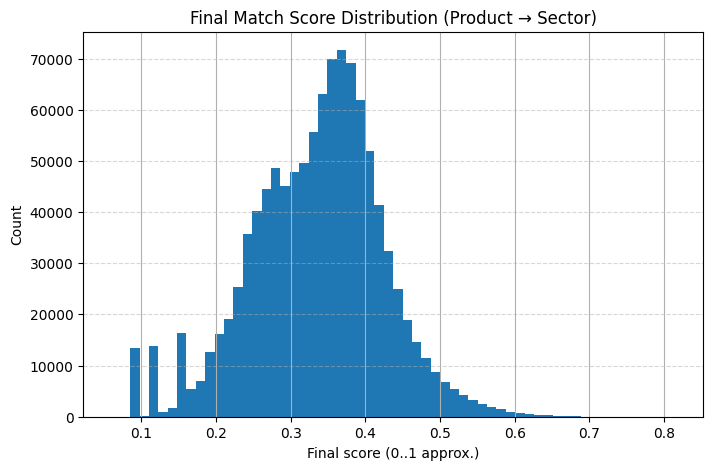

,off_index,product_text,sector_name,semantic_score,fuzzy_score,final_score
0,0,and i'm going to make you a little bit of blac...,{'cultivation of wheat' },0.208413,85.500000,0.402389
1,0,and i'm going to make you a little bit of blac...,{'cultivation of oil seeds' },0.154548,85.500000,0.364683
2,0,and i'm going to make you a little bit of blac...,{'cultivation of paddy rice' },0.148461,85.500000,0.360423
3,1,"banana chips sweetened (whole) bananas, vegeta...",{'cultivation of oil seeds' },0.250315,85.500000,0.431721
4,1,"banana chips sweetened (whole) bananas, vegeta...",{'processing vegetable oils and fats' },0.249803,85.500000,0.431362
5,1,"banana chips sweetened (whole) bananas, vegeta...",{'production of electricity by petroleum and o...,0.181926,85.500000,0.383848
6,2,"peanuts torn & glasser peanuts, wheat flour, s...",{'manufacture of glass and glass products' },0.366811,45.000000,0.391768
7,2,"peanuts torn & glasser peanuts, wheat flour, s...","{'mining of chemical and fertilizer minerals, ...",0.164511,85.500000,0.371658
8,2,"peanuts torn & glasser peanuts, wheat flour, s...",{'p- and other fertiliser' },0.309187,42.352941,0.343490
9,3,organic salted nut mix grizzlies organic hazel...,{'animal products nec' },0.398927,45.000000,0.414249


from matplotlib import pyplot as plt
_df_0['off_index'].plot(kind='hist', bins=20, title='off_index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['semantic_score'].plot(kind='hist', bins=20, title='semantic_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['fuzzy_score'].plot(kind='hist', bins=20, title='fuzzy_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['final_score'].plot(kind='hist', bins=20, title='final_score')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_17['product_text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_17, x='semantic_score', y='product_text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_18['product_text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_18, x='fuzzy_score', y='product_text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['product_text'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='final_score', y='product_text', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [45]:
# ============================
# SmartFootPrintAI — OFF → Sector mapping (full run, with progress bars, no CPU workers)
# Fuzzy shortlist (sequential) + semantic re-ranking (GPU if available)
# Weighted final score + semantic tie-breaker; robust I/O; caching
# ============================

# --- Imports
import os, re, math, json, gc, time
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from unidecode import unidecode
from rapidfuzz import process as fuzzprocess, fuzz as fuzzscore
from sentence_transformers import SentenceTransformer, util
import torch
import matplotlib.pyplot as plt

# ------------------------
# Paths & Drive mount
# ------------------------
DRIVE_ROOT = Path("/content/drive")
if not DRIVE_ROOT.exists():
    from google.colab import drive
    drive.mount('/content/drive')

PROJ_DIR = DRIVE_ROOT / "MyDrive/MRIO_3/SmartFootPrintAI"
OFF_PARQUET = PROJ_DIR / "off_translated.parquet"
SECTORS_XLSX = PROJ_DIR / "Sectors.xlsx"
CACHE_DIR   = PROJ_DIR / "cache"; CACHE_DIR.mkdir(parents=True, exist_ok=True)
MAP_CACHE   = CACHE_DIR / "product_sector_mapping_cache.parquet"
OUT_PARQUET = PROJ_DIR / "product_to_sector_mapping.parquet"

# Fallback search if paths differ
def _find_file(pattern:str, root=PROJ_DIR):
    import glob
    hits = glob.glob(str(root / "**" / pattern), recursive=True)
    return Path(hits[0]) if hits else None

if not OFF_PARQUET.exists():
    hit = _find_file("off_translated.parquet")
    assert hit, "Could not locate off_translated.parquet anywhere under your project."
    OFF_PARQUET = hit

if not SECTORS_XLSX.exists():
    hit = _find_file("Sectors.xlsx")
    assert hit, "Could not locate Sectors.xlsx anywhere under your project."
    SECTORS_XLSX = hit

print("OFF file:", OFF_PARQUET)
print("Sectors file:", SECTORS_XLSX)

# ------------------------
# Config (speed/quality)
# ------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ST_MODEL_NAME = "all-mpnet-base-v2"        # strong general model
TOPK_FUZZY   = 10                           # fuzzy candidates kept per product
TOPK_FINAL   = 3                            # final matches per product
BATCH_SIZE_ENCODE = 2048 if DEVICE == "cuda" else 512  # product embedding batch size

# Score weights
SEMANTIC_WEIGHT = 0.7
FUZZY_WEIGHT    = 0.3
TIE_THRESHOLD   = 1e-4   # if final scores differ <= threshold, prefer higher semantic

# ------------------------
# Text helpers
# ------------------------
def _norm_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = unidecode(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = re.sub(r"[\u0000-\u001f]", " ", s)
    return s

def _norm_header(c: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", str(c).strip().lower())

# ------------------------
# Input hardening
# ------------------------
def ensure_off_text(off_df: pd.DataFrame) -> pd.DataFrame:
    """Guarantee a normalized 'text_en' column."""
    if "text_en" not in off_df.columns:
        for alt in ["product_name_en","product_name","text_raw","name","title"]:
            if alt in off_df.columns:
                off_df = off_df.rename(columns={alt: "text_en"})
                break
    if "text_en" not in off_df.columns:
        raise KeyError(f"OFF df lacks 'text_en'. Columns: {off_df.columns.tolist()}")
    off_df = off_df.copy()
    off_df["text_en"] = off_df["text_en"].astype(str).map(_norm_text)
    return off_df

def ensure_sector_name(sectors_df: pd.DataFrame) -> pd.DataFrame:
    """Return a 1-col df with 'sector_name', auto-detecting CPC/description headers."""
    original = list(sectors_df.columns)
    sectors_df = sectors_df.rename(columns={c: _norm_header(c) for c in sectors_df.columns})
    candidates = [
        "sector_name","sector","sector_desc","sector_description",
        "name","description","desc","cpc_description","cpc_desc",
        "industry","industry_name","exio_sector","exio_description"
    ]
    pick = None
    for c in candidates:
        if c in sectors_df.columns:
            pick = c; break
    if pick is None:
        # Heuristic: column with most non-empty strings
        def score(c):
            s = sectors_df[c].astype(str).str.strip()
            return (s.str.len() > 0).sum()
        pick = max(sectors_df.columns, key=score)

    out = sectors_df[[pick]].copy()
    out.columns = ["sector_name"]
    out["sector_name"] = out["sector_name"].astype(str).map(_norm_text)
    out = out[out["sector_name"].str.len() > 0].drop_duplicates("sector_name").reset_index(drop=True)
    if out.empty:
        raise ValueError(f"No non-empty sector names found. Original headers: {original}")
    print(f"[ensure_sector_name] Using column '{pick}' -> 'sector_name'. Rows: {len(out)}")
    return out

# ------------------------
# Fuzzy shortlist over ALL unique products — sequential (no workers), with progress
# ------------------------
def fuzzy_shortlist_sequential(products_unique, sector_names, topk=TOPK_FUZZY):
    """
    Returns dict: product_text -> [(sector_idx, sector_name, fuzzy_score), ...]
    Sequential loop with tqdm progress (no CPU threading).
    """
    name_to_matches = {}
    for name in tqdm(products_unique, total=len(products_unique), desc="Step 1/3: Fuzzy shortlist (sequential)"):
        matches = fuzzprocess.extract(name, sector_names, scorer=fuzzscore.WRatio, limit=topk)
        name_to_matches[name] = [(m[2], m[0], m[1]) for m in matches]  # (sector_idx, sector_name, score)
    return name_to_matches

# ------------------------
# Main mapper — progress bars for each major phase
# ------------------------
def map_products_to_sectors_all(off_df: pd.DataFrame, sectors_df: pd.DataFrame,
                                force_recompute: bool=False) -> pd.DataFrame:
    # 1) Normalize
    off_df = ensure_off_text(off_df)
    sectors_df = ensure_sector_name(sectors_df)

    product_all = off_df["text_en"].astype(str).tolist()
    sector_names = sectors_df["sector_name"].astype(str).tolist()

    # 2) Cache load
    cache = {}
    if MAP_CACHE.exists() and not force_recompute:
        c = pd.read_parquet(MAP_CACHE)
        cache = {(r.product_text, r.sector_name): (r.semantic_score, r.fuzzy_score) for r in c.itertuples()}
        print(f"[cache] Loaded {len(cache):,} entries")

    # 3) Pre-encode sector embeddings (once)
    print("[emb] Encoding sector embeddings...")
    st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)
    sector_emb = st_model.encode(sector_names, convert_to_tensor=True, show_progress_bar=True)
    index_of_sector = {name: i for i, name in enumerate(sector_names)}

    # 4) Unique products
    uniq_products = pd.Index(product_all).unique().tolist()
    print(f"Unique products: {len(uniq_products):,}  |  Total rows: {len(product_all):,}")

    # 5) Fuzzy shortlist (sequential)
    fuzzy_dict = fuzzy_shortlist_sequential(uniq_products, sector_names, topk=TOPK_FUZZY)

    # 6) Batch-encode product embeddings for ALL unique products (GPU if available)
    print("[emb] Encoding product embeddings in batches...")
    prod_embeds = {}
    for i in tqdm(range(0, len(uniq_products), BATCH_SIZE_ENCODE), desc="Step 2/3: Product embedding batches"):
        batch = uniq_products[i:i+BATCH_SIZE_ENCODE]
        embs = st_model.encode(batch, convert_to_tensor=True, show_progress_bar=False)
        for j, name in enumerate(batch):
            prod_embeds[name] = embs[j]

    # 7) Score + choose top matches per product
    per_product_best = {}  # product_text -> list of (sector_name, sem, fuzz, final)
    cache_hits = 0
    pbar = tqdm(uniq_products, desc="Step 3/3: Semantic re-ranking + combine")
    for name in pbar:
        # cache reuse
        cached_entries = [(sec, sc[0], sc[1]) for (prod, sec), sc in cache.items() if prod == name]
        if cached_entries:
            cache_hits += 1
            rows = []
            for sec, sem_sc, fuzz_sc in cached_entries:
                final_sc = SEMANTIC_WEIGHT * sem_sc + FUZZY_WEIGHT * (fuzz_sc / 100.0)
                rows.append((sec, sem_sc, fuzz_sc, final_sc))
            rows.sort(key=lambda x: (round(x[3], 6), x[1]), reverse=True)
            per_product_best[name] = rows[:TOPK_FINAL]
            if cache_hits % 5000 == 0:
                pbar.set_postfix_str(f"cache_hits={cache_hits}")
            continue

        shortlist = fuzzy_dict.get(name, [])
        if not shortlist:
            per_product_best[name] = []
            continue

        # Select sector embedding rows by index from shortlist
        sec_indices = [t[0] for t in shortlist]
        sec_fuzzy   = {t[1]: t[2] for t in shortlist}  # sector_name -> fuzzy_score
        sec_names_short = [sector_names[k] for k in sec_indices]

        prod_vec = prod_embeds[name]
        sec_vecs = sector_emb[sec_indices]

        # cosine similarity (1 x K)
        sem_scores = util.cos_sim(prod_vec, sec_vecs)[0].detach().cpu().numpy()

        rows = []
        for sec_nm, sem_sc in zip(sec_names_short, sem_scores):
            fuzz_sc = sec_fuzzy[sec_nm]
            final_sc = SEMANTIC_WEIGHT * sem_sc + FUZZY_WEIGHT * (fuzz_sc / 100.0)
            rows.append((sec_nm, float(sem_sc), float(fuzz_sc), float(final_sc)))

        rows.sort(key=lambda x: (round(x[3], 6), x[1]), reverse=True)
        rows = rows[:TOPK_FINAL]
        per_product_best[name] = rows
        for sec_nm, sem_sc, fuzz_sc, _final_sc in rows:
            cache[(name, sec_nm)] = (float(sem_sc), float(fuzz_sc))

    # 8) Persist cache
    cache_df = pd.DataFrame(
        [(prod, sec, sem, fuzz) for (prod, sec), (sem, fuzz) in cache.items()],
        columns=["product_text","sector_name","semantic_score","fuzzy_score"]
    )
    cache_df.to_parquet(MAP_CACHE, engine="pyarrow", compression="snappy")
    print(f"[cache] Saved {len(cache_df):,} entries → {MAP_CACHE}")

    # 9) Expand back to ALL rows — with progress
    rows_out = []
    for off_idx, prod_text in tqdm(list(enumerate(product_all)),
                                   total=len(product_all),
                                   desc="Expanding matches back to all rows"):
        matches = per_product_best.get(prod_text, [])
        if not matches:
            continue
        for sec_nm, sem_sc, fuzz_sc, final_sc in matches:
            rows_out.append((off_idx, prod_text, sec_nm, sem_sc, fuzz_sc, final_sc))

    out = pd.DataFrame(rows_out, columns=["off_index","product_text","sector_name","semantic_score","fuzzy_score","final_score"])
    out.sort_values(["off_index","final_score","semantic_score"], ascending=[True, False, False], inplace=True)
    out.reset_index(drop=True, inplace=True)
    return out

# ------------------------
# Load data and run full mapping (with progress)
# ------------------------
df_off = pd.read_parquet(OFF_PARQUET)
sectors_raw = pd.read_excel(SECTORS_XLSX)

print("OFF columns:", df_off.columns.tolist())
print("Sectors columns:", sectors_raw.columns.tolist())

mapping_df = map_products_to_sectors_all(df_off, sectors_raw, force_recompute=False)

# Save results
mapping_df.to_parquet(OUT_PARQUET, engine="pyarrow", compression="snappy")
print("✅ Mapping complete:", mapping_df.shape, "→", OUT_PARQUET)

# ------------------------
# Visual quick-check (final score distribution)
# ------------------------
plt.figure(figsize=(8,5))
mapping_df["final_score"].hist(bins=60)
plt.title("Final Match Score Distribution (Product → Sector)")
plt.xlabel("Final score (0..1 approx.)")
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Peek
display(mapping_df.head(10))


In [ ]:
from matplotlib import pyplot as plt
_df_12['off_index'].plot(kind='line', figsize=(8, 4), title='off_index')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('product_text').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

⏳ Encoding embeddings for UMAP…


Batches:   0%|          | 0/255 [00:00<?, ?it/s]

⏳ Running UMAP…


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


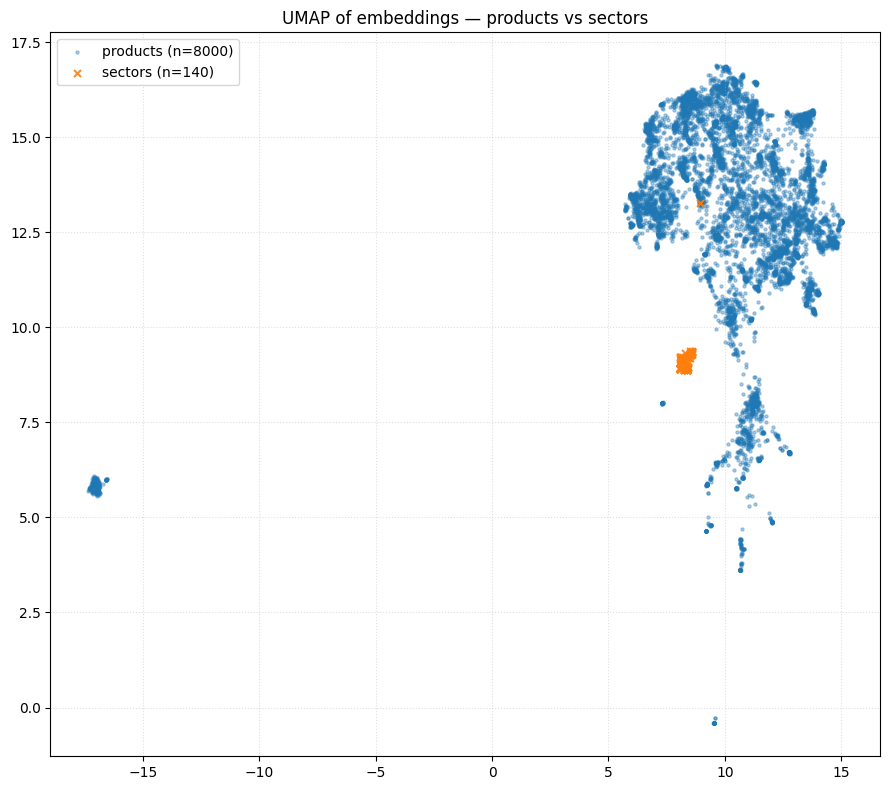

Saved: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/umap_products_vs_sectors.png
⏳ Building confusion map…


/tmp/ipython-input-1620456120.py:183: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


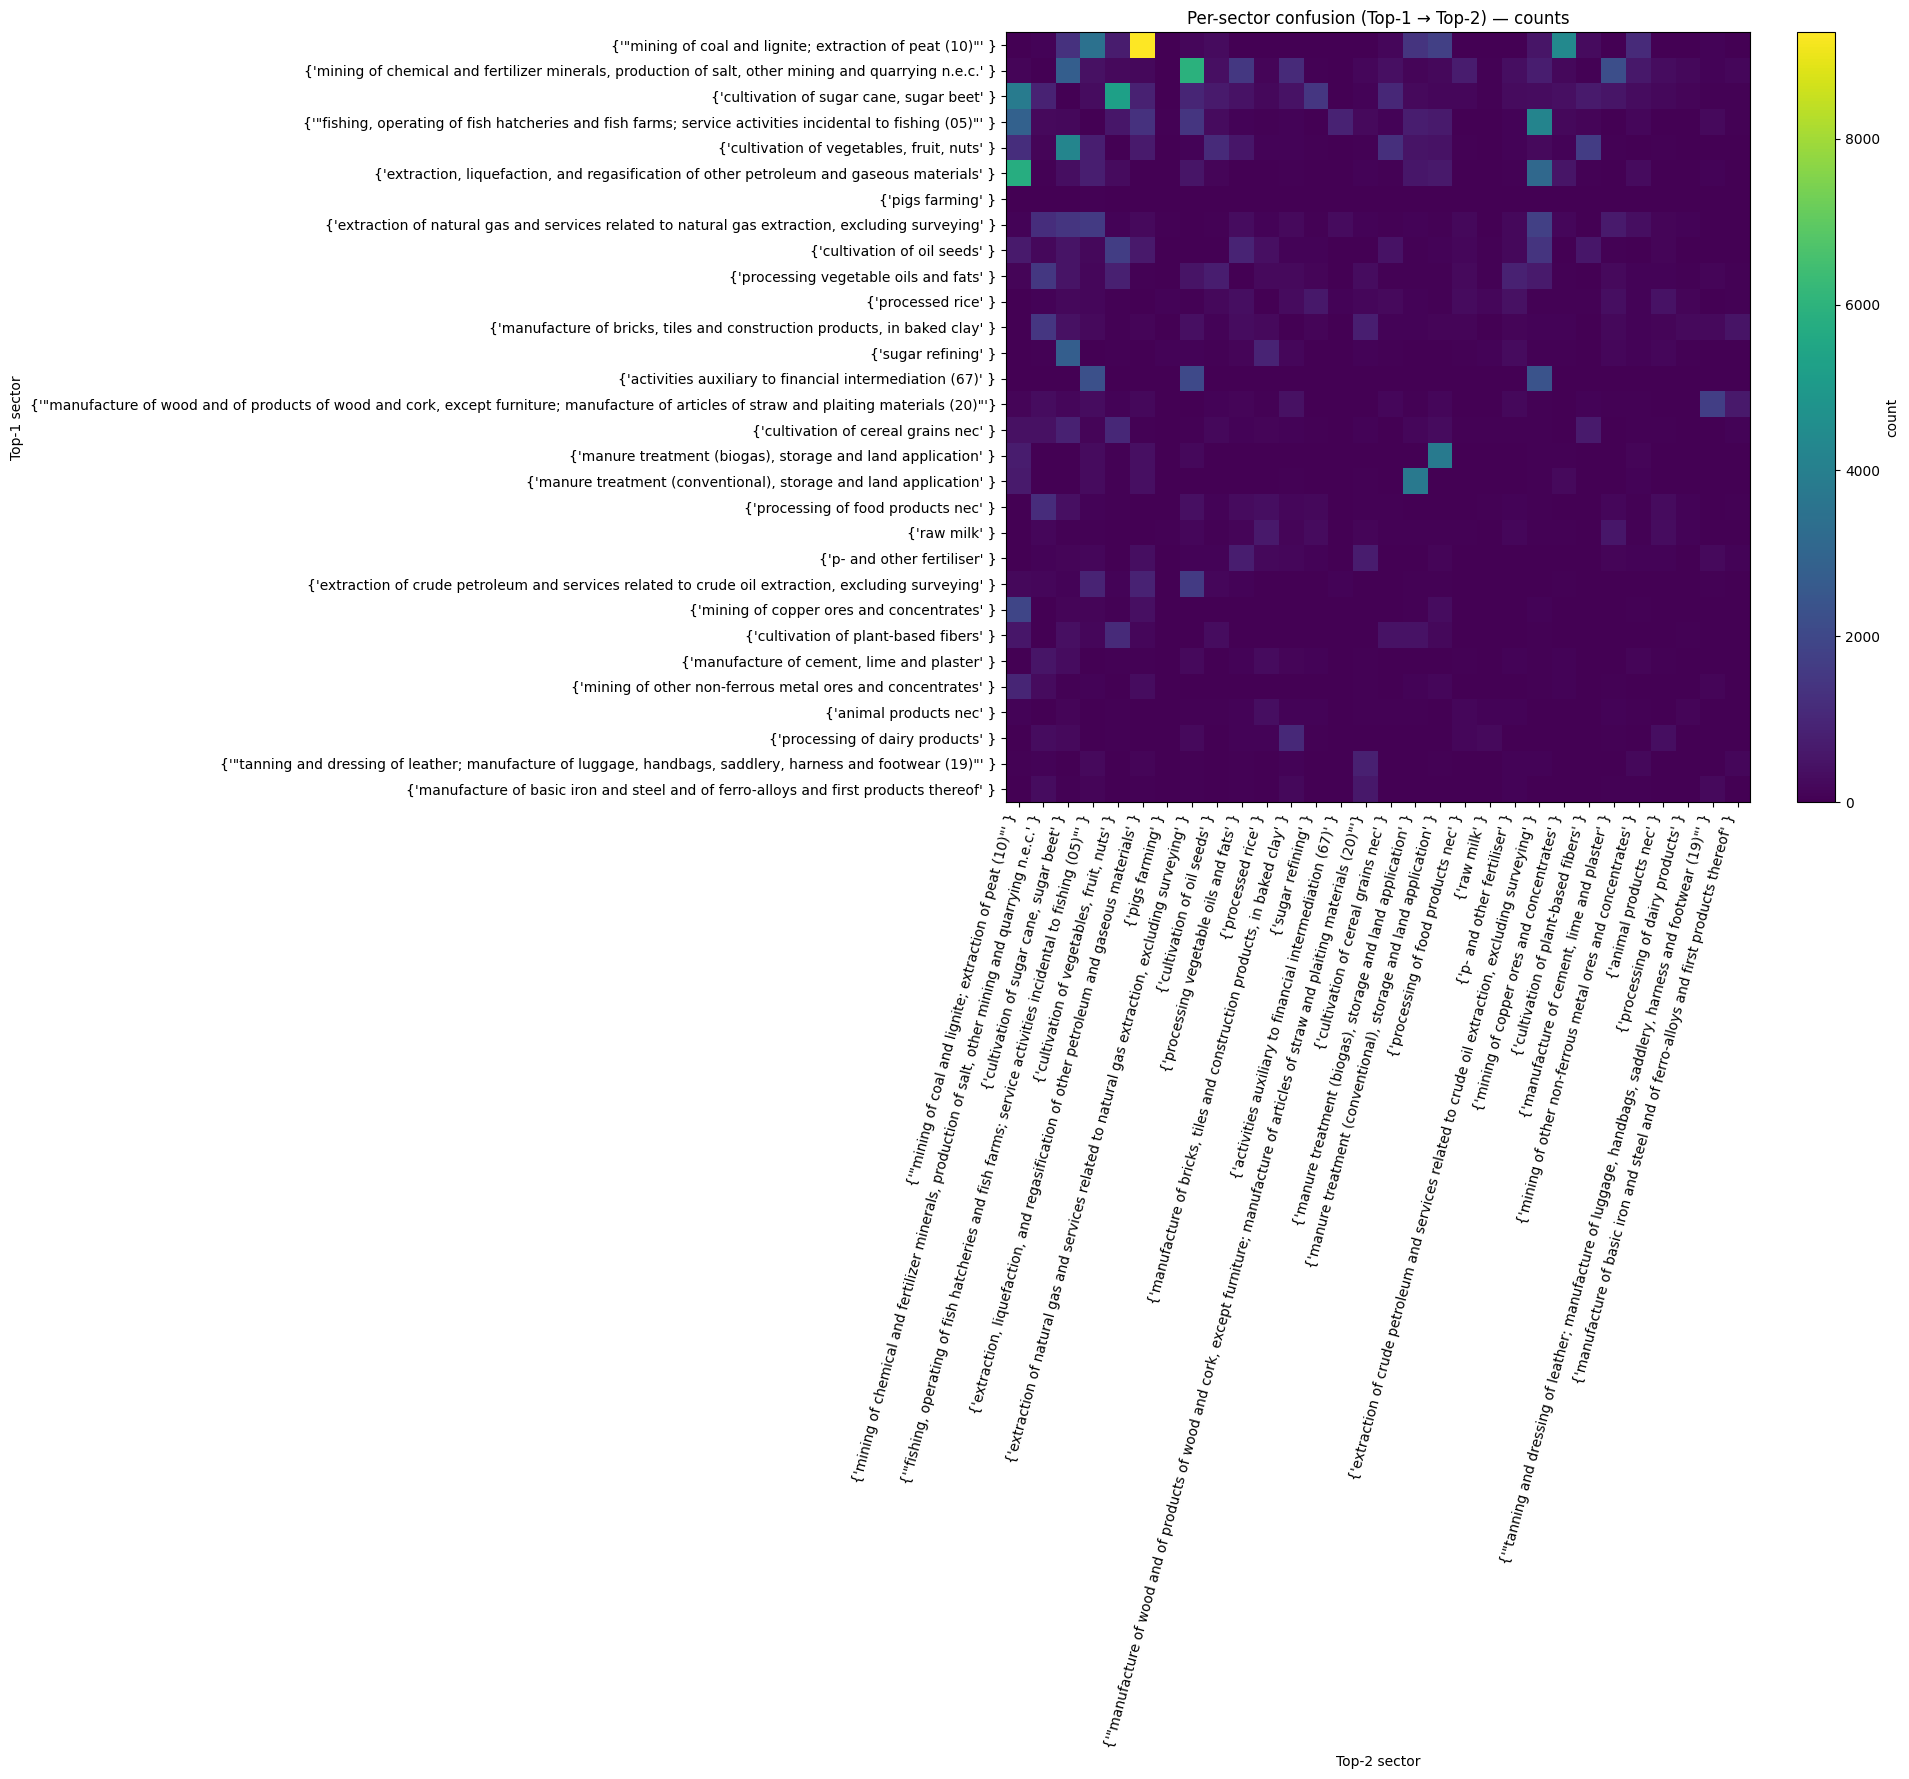

Saved: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/confusion_top1_to_top2_counts.png


/tmp/ipython-input-1620456120.py:198: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


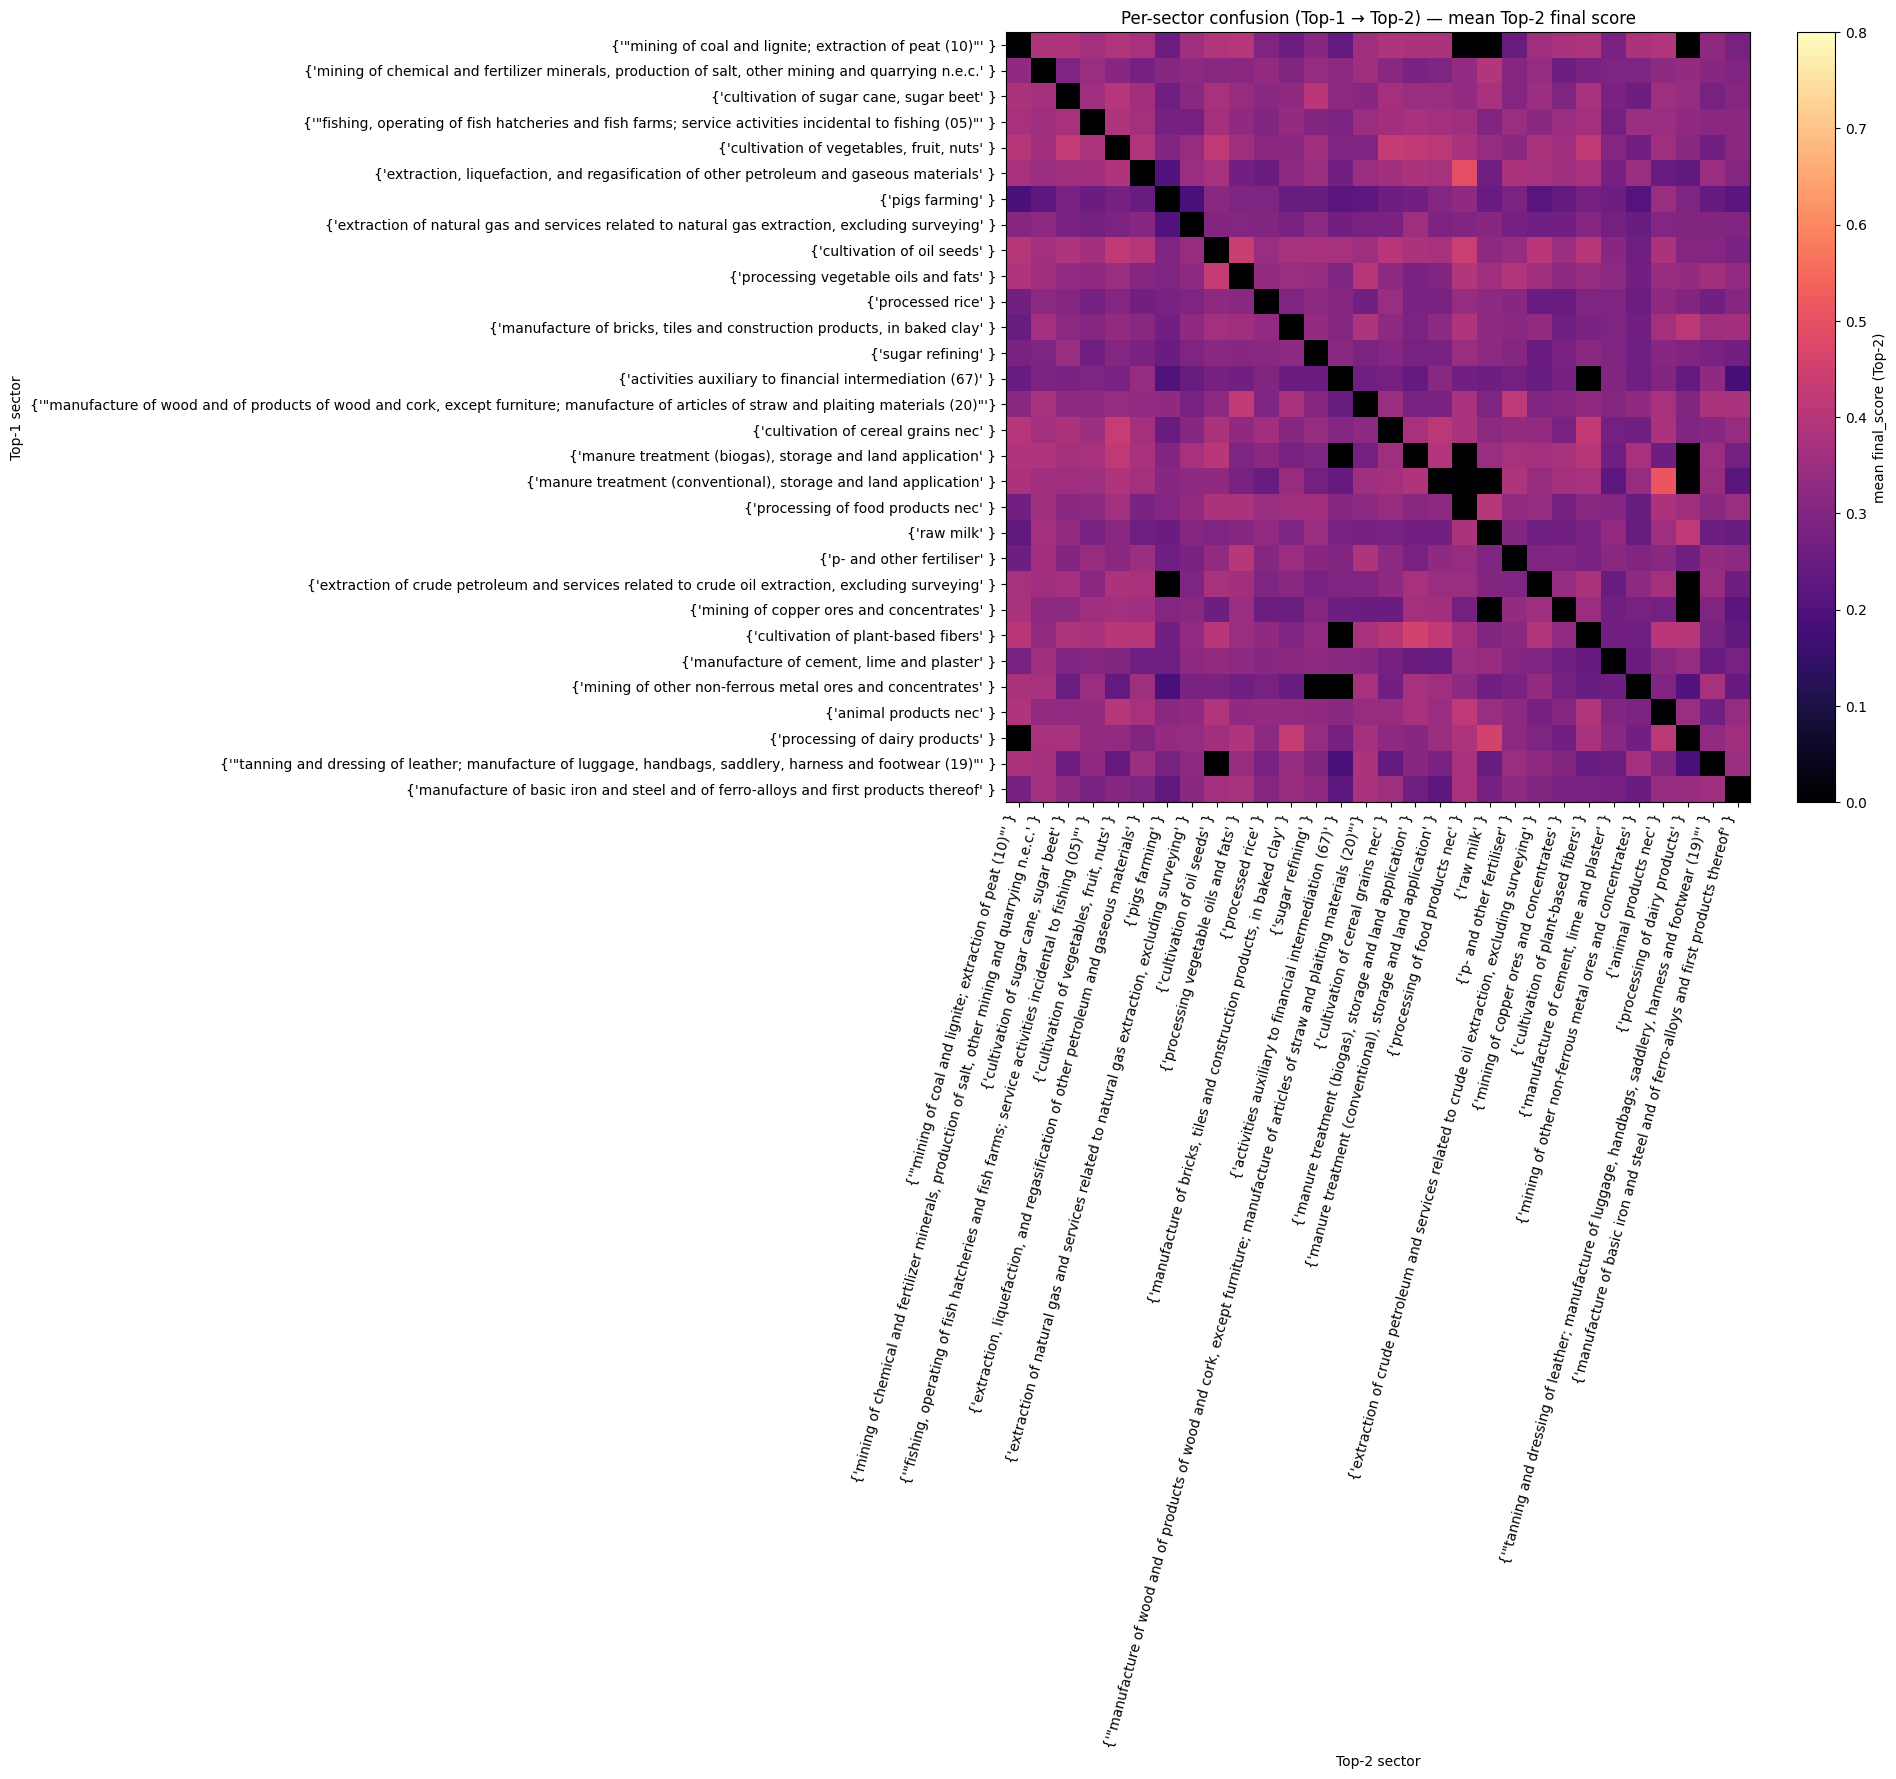

Saved: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/confusion_top1_to_top2_mean_score.png
Exported: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/confusion_pairs_long.csv
⏳ Preparing Sankey flow…


/tmp/ipython-input-1620456120.py:267: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flow = flow.groupby("sector_group", group_keys=False).apply(lambda d: top_k_per_group(d, TOP_SECTORS_PER_GROUP))


Saved Sankey to: /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/sankey_sector_group_to_sector.html
✅ Done. Outputs:
 - /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/umap_products_vs_sectors.png
 - /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/confusion_top1_to_top2_counts.png
 - /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/confusion_top1_to_top2_mean_score.png
 - /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/confusion_pairs_long.csv
 - /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/mapping_diagnostics_deep/sankey_sector_group_to_sector.html


In [46]:
# =========================================
# SmartFootPrintAI — Deep visuals for OFF → Sector mapping
# 1) UMAP of embeddings (needs umap-learn)
# 2) Per-sector confusion heatmap
# 3) Sankey (“Shapley-style”) flow from sector groups → sectors
# =========================================

# --- Optional installs (safe to re-run) ---
try:
    import umap  # noqa
except Exception:
    !pip -q install umap-learn==0.5.6 > /dev/null
try:
    import plotly  # noqa
except Exception:
    !pip -q install plotly==5.22.0 > /dev/null

# --- Imports
import os, re, math, json, gc, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sentence_transformers import SentenceTransformer
import torch

import plotly.graph_objects as go
import umap  # type: ignore

# ------------------------
# Paths
# ------------------------
try:
    PROJ_DIR = PROJ_DIR
except NameError:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    PROJ_DIR = Path("/content/drive/MyDrive/MRIO_3/SmartFootPrintAI")

MAPPING_PARQUET = PROJ_DIR / "product_to_sector_mapping.parquet"
SECTORS_XLSX    = PROJ_DIR / "Sectors.xlsx"

def _find_file(pattern:str, root=PROJ_DIR):
    import glob
    hits = glob.glob(str(root / "**" / pattern), recursive=True)
    return Path(hits[0]) if hits else None

if not MAPPING_PARQUET.exists():
    hit = _find_file("product_to_sector_mapping.parquet")
    assert hit, "Could not locate product_to_sector_mapping.parquet"
    MAPPING_PARQUET = hit
if not SECTORS_XLSX.exists():
    hit = _find_file("Sectors.xlsx")
    SECTORS_XLSX = hit if hit else None

OUT_DIR = PROJ_DIR / "mapping_diagnostics_deep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------
# Config (reusing your mapping settings if present)
# ------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ST_MODEL_NAME = globals().get("ST_MODEL_NAME", "all-mpnet-base-v2")
TIE_THRESHOLD = globals().get("TIE_THRESHOLD", 1e-4)
TOPK_FINAL = globals().get("TOPK_FINAL", 3)

# ------------------------
# Load data
# ------------------------
mapping_df = pd.read_parquet(MAPPING_PARQUET)
# Expected columns: off_index, product_text, sector_name, semantic_score, fuzzy_score, final_score
assert {"off_index","product_text","sector_name","semantic_score","fuzzy_score","final_score"} <= set(mapping_df.columns), \
    f"mapping_df missing columns: {mapping_df.columns.tolist()}"

# Keep only Top-k per product_index (in case file includes more)
mapping_df = mapping_df.sort_values(
    ["off_index","final_score","semantic_score"], ascending=[True, False, False]
).groupby("off_index", as_index=False, group_keys=False).head(TOPK_FINAL)

# ------------------------
# Helper: normalize text
# ------------------------
def _norm_text(s: str) -> str:
    if not isinstance(s, str): return ""
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

mapping_df["product_text"] = mapping_df["product_text"].astype(str).map(_norm_text)
mapping_df["sector_name"]  = mapping_df["sector_name"].astype(str).map(_norm_text)

# ============================================================
# 1) UMAP of product & sector embeddings
# ============================================================
print("⏳ Encoding embeddings for UMAP…")
st_model = SentenceTransformer(ST_MODEL_NAME, device=DEVICE)

# Choose a manageable subset of products for plotting (to keep the figure readable)
MAX_PRODUCTS = 8000
prod_top1 = (
    mapping_df.sort_values(["off_index","final_score","semantic_score"], ascending=[True, False, False])
              .groupby("off_index", as_index=False, group_keys=False).head(1)
              [["off_index","product_text","sector_name","final_score"]]
              .drop_duplicates("off_index")
)
if len(prod_top1) > MAX_PRODUCTS:
    prod_top1 = prod_top1.sample(MAX_PRODUCTS, random_state=42)

# Unique sectors in the mapping
sectors = pd.Index(mapping_df["sector_name"].unique()).tolist()

# Encode
prod_names = prod_top1["product_text"].tolist()
sec_names  = sectors
all_texts  = prod_names + sec_names

emb = st_model.encode(all_texts, convert_to_numpy=True, show_progress_bar=True, device=DEVICE)
prod_emb = emb[:len(prod_names)]
sec_emb  = emb[len(prod_names):]

# UMAP (2D)
print("⏳ Running UMAP…")
um = umap.UMAP(n_neighbors=30, min_dist=0.05, n_components=2, metric="cosine", random_state=42)
xy = um.fit_transform(emb)
xy_prod = xy[:len(prod_names)]
xy_sec  = xy[len(prod_names):]

# Plot
plt.figure(figsize=(9,8))
plt.scatter(xy_prod[:,0], xy_prod[:,1], s=5, alpha=0.35, label=f"products (n={len(prod_names)})")
plt.scatter(xy_sec[:,0],  xy_sec[:,1],  s=25, alpha=0.9,  label=f"sectors (n={len(sec_names)})", marker="x")
plt.title("UMAP of embeddings — products vs sectors")
plt.legend(loc="best")
plt.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
umap_path = OUT_DIR / "umap_products_vs_sectors.png"
plt.savefig(umap_path, dpi=150)
plt.show()
print("Saved:", umap_path)

# ============================================================
# 2) Per-sector confusion map
#    Idea: For each product, take Top-1 and Top-2 sectors → increment s1→s2
#          Heatmap over top sectors by frequency.
# ============================================================
print("⏳ Building confusion map…")
# Ensure we have Top-2 per product (if available)
top_sorted = mapping_df.sort_values(["off_index","final_score","semantic_score"], ascending=[True, False, False])
top2 = top_sorted.groupby("off_index", as_index=False, group_keys=False).head(2)
s1 = top2.groupby("off_index").nth(0).reset_index()
s2 = top2.groupby("off_index").nth(1).reset_index()

conf = s1.merge(s2, on="off_index", suffixes=("_1","_2"), how="inner")
# Matrix over most frequent Top-1 sectors to keep the chart readable
topS = s1["sector_name"].value_counts().head(30).index.tolist()
conf = conf[conf["sector_name_1"].isin(topS) & conf["sector_name_2"].isin(topS)]

# Build count & mean score matrices
sec_to_idx = {s:i for i,s in enumerate(topS)}
mat_count = np.zeros((len(topS), len(topS)), dtype=np.int32)
mat_mean  = np.zeros((len(topS), len(topS)), dtype=np.float32)
accum_sum = np.zeros_like(mat_mean)

for _, r in conf.iterrows():
    i = sec_to_idx[r["sector_name_1"]]
    j = sec_to_idx[r["sector_name_2"]]
    mat_count[i, j] += 1
    accum_sum[i, j] += float(r["final_score_2"])

# Avoid divide-by-zero
with np.errstate(invalid="ignore", divide="ignore"):
    mat_mean = np.where(mat_count>0, accum_sum / np.maximum(mat_count, 1), 0.0)

# Plot counts heatmap
plt.figure(figsize=(12,10))
plt.imshow(mat_count, cmap="viridis", aspect="auto")
plt.title("Per-sector confusion (Top-1 → Top-2) — counts")
plt.colorbar(label="count")
plt.xticks(ticks=np.arange(len(topS)), labels=topS, rotation=75, ha="right")
plt.yticks(ticks=np.arange(len(topS)), labels=topS)
plt.xlabel("Top-2 sector")
plt.ylabel("Top-1 sector")
plt.tight_layout()
hm_count_path = OUT_DIR / "confusion_top1_to_top2_counts.png"
plt.savefig(hm_count_path, dpi=150)
plt.show()
print("Saved:", hm_count_path)

# Plot mean final score heatmap (of Top-2)
plt.figure(figsize=(12,10))
plt.imshow(mat_mean, cmap="magma", aspect="auto", vmin=0.0, vmax=max(0.8, np.nanmax(mat_mean)))
plt.title("Per-sector confusion (Top-1 → Top-2) — mean Top-2 final score")
plt.colorbar(label="mean final_score (Top-2)")
plt.xticks(ticks=np.arange(len(topS)), labels=topS, rotation=75, ha="right")
plt.yticks(ticks=np.arange(len(topS)), labels=topS)
plt.xlabel("Top-2 sector")
plt.ylabel("Top-1 sector")
plt.tight_layout()
hm_mean_path = OUT_DIR / "confusion_top1_to_top2_mean_score.png"
plt.savefig(hm_mean_path, dpi=150)
plt.show()
print("Saved:", hm_mean_path)

# Export long-form confusion table too
conf_out = OUT_DIR / "confusion_pairs_long.csv"
conf[["sector_name_1","sector_name_2","final_score_1","final_score_2"]].to_csv(conf_out, index=False)
print("Exported:", conf_out)

# ============================================================
# 3) Sankey (“Shapley-style”) flow: sector_group → sector (width = #Top-1 products)
#    We try to derive a 'sector group' from Sectors.xlsx; if none, fallback = first token of sector name
# ============================================================
print("⏳ Preparing Sankey flow…")
# Build Top-1 list
top1 = top_sorted.groupby("off_index", as_index=False, group_keys=False).head(1)[["off_index","product_text","sector_name"]]

# Try load sector groups
sector_groups = None
if SECTORS_XLSX and Path(SECTORS_XLSX).exists():
    sec_df = pd.read_excel(SECTORS_XLSX)
    sec_cols = {c.lower(): c for c in sec_df.columns}
    # Look for a grouping-ish column
    group_key = None
    for cand in ["cpc_section","section","cpc_division","division","cpc_group","group","parent","category"]:
        if cand in sec_cols:
            group_key = sec_cols[cand]; break
    name_key = None
    for cand in ["cpc_description","sector","sector_name","description","name","industry","exio_sector","exio_description"]:
        if cand in sec_cols:
            name_key = sec_cols[cand]; break

    if name_key:
        tmp = sec_df[[name_key]].copy()
        tmp.columns = ["sector_name"]
        if group_key and group_key in sec_df.columns:
            tmp[group_key] = sec_df[group_key].astype(str)
            sector_groups = tmp.rename(columns={group_key: "sector_group"}).copy()
        else:
            sector_groups = tmp.copy()
            sector_groups["sector_group"] = sector_groups["sector_name"].astype(str).str.split().str[0]
        sector_groups["sector_name"]  = sector_groups["sector_name"].astype(str).map(_norm_text)
        sector_groups["sector_group"] = sector_groups["sector_group"].astype(str).map(_norm_text)

# Fallback if no Sectors.xlsx or no grouping column
if sector_groups is None or sector_groups.empty:
    tmp_names = pd.DataFrame({"sector_name": pd.Index(mapping_df["sector_name"].unique()).astype(str)})
    tmp_names["sector_group"] = tmp_names["sector_name"].astype(str).str.split().str[0]
    tmp_names["sector_name"]  = tmp_names["sector_name"].map(_norm_text)
    tmp_names["sector_group"] = tmp_names["sector_group"].map(_norm_text)
    sector_groups = tmp_names

# Merge group labels to top1
top1g = top1.merge(sector_groups, on="sector_name", how="left")
top1g["sector_group"] = top1g["sector_group"].fillna("(other)")

# Aggregate counts
flow = (top1g.groupby(["sector_group","sector_name"], as_index=False)
              .agg(n_products=("off_index","count")))
# Limit to top N groups/sectors for readability
TOP_GROUPS = 15
TOP_SECTORS_PER_GROUP = 8
top_groups = flow.groupby("sector_group")["n_products"].sum().sort_values(ascending=False).head(TOP_GROUPS).index.tolist()
flow = flow[flow["sector_group"].isin(top_groups)].copy()

def top_k_per_group(df, k):
    return (df.sort_values("n_products", ascending=False).head(k))
flow = flow.groupby("sector_group", group_keys=False).apply(lambda d: top_k_per_group(d, TOP_SECTORS_PER_GROUP))

# Build Sankey nodes and links
groups = pd.Index(flow["sector_group"].unique()).tolist()
sectors = pd.Index(flow["sector_name"].unique()).tolist()
nodes = groups + sectors
node_index = {n:i for i,n in enumerate(nodes)}

links_source = []
links_target = []
links_value  = []
for _, r in flow.iterrows():
    links_source.append(node_index[r["sector_group"]])
    links_target.append(node_index[r["sector_name"]])
    links_value.append(int(r["n_products"]))

# Make nicer labels for display
def pretty(s):
    s = str(s)
    return s[:40] + ("…" if len(s)>40 else "")
node_labels = [f"Group: {pretty(g)}" for g in groups] + [f"Sector: {pretty(s)}" for s in sectors]

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node = dict(
        pad=12,
        thickness=14,
        line=dict(color="black", width=0.2),
        label=node_labels
    ),
    link = dict(
        source=links_source,
        target=links_target,
        value=links_value
    )
)])
fig.update_layout(title_text="Flow of product mappings: sector group → sector (width = #Top-1 products)", font_size=12)

sankey_path = OUT_DIR / "sankey_sector_group_to_sector.html"
fig.write_html(str(sankey_path))
print("Saved Sankey to:", sankey_path)

print("✅ Done. Outputs:")
print(" -", OUT_DIR / "umap_products_vs_sectors.png")
print(" -", OUT_DIR / "confusion_top1_to_top2_counts.png")
print(" -", OUT_DIR / "confusion_top1_to_top2_mean_score.png")
print(" -", OUT_DIR / "confusion_pairs_long.csv")
print(" -", sankey_path)


In [50]:
import plotly.graph_objects as go
import plotly.io as pio

# Force Plotly to render inline in Colab/Jupyter
pio.renderers.default = "colab"  # For Google Colab
# pio.renderers.default = "notebook"  # For Jupyter Notebook/Lab

# Example: Sankey nodes + links from mapping_df
product_nodes = list(mapping_df['product_text'].unique())[:20]  # sample top 20
sector_nodes = list(mapping_df['sector_name'].unique())[:20]
nodes = product_nodes + sector_nodes

# Build index maps
node_indices = {name: idx for idx, name in enumerate(nodes)}

# Example links (random counts for demo; replace with your aggregation)
links = []
for prod in product_nodes:
    matches = mapping_df[mapping_df['product_text'] == prod]['sector_name'].value_counts().head(1)
    for sec, count in matches.items():
        if sec in node_indices:
            links.append({
                "source": node_indices[prod],
                "target": node_indices[sec],
                "value": count
            })

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=[l["source"] for l in links],
        target=[l["target"] for l in links],
        value=[l["value"] for l in links]
    )
)])

fig.update_layout(title_text="Product → Sector Mapping Sankey", font_size=10)
fig.show()



## 7) LCA data (Clark et al.) + FAOSTAT prices → harmonize units & keep (CO₂, Land, Water)

In [58]:
# SmartFootPrintAI — Robust OFF → LCA → FAOSTAT → Sector aggregation (ALL products)

import re, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ----------------------
# Paths (adapt if needed)
# ----------------------
DRIVE_ROOT = Path("/content/drive")
PROJ_DIR   = DRIVE_ROOT / "MyDrive/MRIO_3/SmartFootPrintAI"
IN_MAP     = PROJ_DIR / "product_to_sector_mapping.parquet"
IN_OFF_LCA = PROJ_DIR / "openfoodfacts_products_with_lca (3) (1).csv"
IN_FAO     = PROJ_DIR / "FAOSTAT_data_en_7-27-2025 (1) (1).csv"
IN_CLARK   = PROJ_DIR / "Environmental impacts of food (Clark et al. 2022) (2) (1) (1).csv"

OUT_DIR    = PROJ_DIR / "harmonized_micro"; OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PROD   = OUT_DIR / "all_products_off_lca_x_price.csv"
OUT_SECT   = OUT_DIR / "all_products_micro_extension_sector_level.csv"

# ----------------------
# Helpers
# ----------------------
def norm_text(s):
    if not isinstance(s, str): return ""
    s = s.strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

def to_usd_per_kg(unit_str, value):
    if pd.isna(value): return np.nan
    u = str(unit_str)
    if re.search(r"/\s*kg\b", u, flags=re.I): return float(value)
    if re.search(r"/\s*(ton(ne)?|t)\b", u, flags=re.I): return float(value) / 1000.0
    return np.nan

def wmean(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    m = ~np.isnan(v) & ~np.isnan(w) & (w > 0)
    if not np.any(m): return np.nan
    return float(np.average(v[m], weights=w[m]))

def uniquify_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Ensures no duplicate column labels (prevents pandas reindex issues later)
    counts = {}
    new_cols = []
    for c in df.columns:
        if c not in counts:
            counts[c] = 1
            new_cols.append(c)
        else:
            counts[c] += 1
            new_cols.append(f"{c}__{counts[c]}")
    df.columns = new_cols
    return df

def read_csv_any(path: Path, **kw):
    # Slightly more robust CSV loader
    for enc in (None, "utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except Exception:
            continue
    # last try with engine
    return pd.read_csv(path, encoding="latin-1", engine="python", **kw)

# ----------------------
# Load mapping
# ----------------------
if not IN_MAP.exists():
    raise FileNotFoundError(f"Missing mapping file: {IN_MAP}")

map_df = pd.read_parquet(IN_MAP)
need_cols = {"product_text","sector_name"}
missing = need_cols - set(map_df.columns)
if missing:
    raise KeyError(f"Mapping file missing columns {missing}. Columns: {map_df.columns.tolist()}")

# normalize + keep best mapping per product if duplicates
map_df["product_text"] = map_df["product_text"].astype(str).map(norm_text)
map_df["sector_name"]  = map_df["sector_name"].astype(str).map(norm_text)
if "final_score" not in map_df.columns:
    map_df["final_score"] = 1.0
map_df["final_score"] = pd.to_numeric(map_df["final_score"], errors="coerce").fillna(0.0)

# If multiple rows per product, keep them all (weighted agg later), but drop exact dups
map_df = (map_df
          .drop_duplicates(subset=["product_text","sector_name","final_score"])
          .reset_index(drop=True))

# ----------------------
# Load OFF (+ normalize/aggregate)
# ----------------------
if not IN_OFF_LCA.exists():
    raise FileNotFoundError(f"Missing OFF file: {IN_OFF_LCA}")

off = read_csv_any(IN_OFF_LCA)
off = uniquify_columns(off)
off_cols = set(off.columns)

# Product text
prod_name_col = "product_name" if "product_name" in off_cols else \
                "product_name_raw" if "product_name_raw" in off_cols else \
                next(iter(off_cols))  # fallback first col
off = off.rename(columns={prod_name_col:"product_name_raw"})
off["product_text"] = off["product_name_raw"].astype(str).map(norm_text)

# LCA columns (best-effort)
lca_name_col = "lca_food_group" if "lca_food_group" in off.columns else None
co2_col  = "co2_kg_per_kg" if "co2_kg_per_kg" in off.columns else None
land_col = "land_use_m2_per_kg" if "land_use_m2_per_kg" in off.columns else None
water_col = None
for cand in ("water_kg_per_kg","water_l_per_kg","water_per_kg"):
    if cand in off.columns: water_col = cand; break

# Build a clean per-product LCA by aggregating duplicates consistently
agg_parts = {"product_text": ("product_text","first")}
if lca_name_col: agg_parts["lca_item_off"] = (lca_name_col, lambda s: norm_text(next((x for x in s.dropna().astype(str) if x.strip()), "")))
if co2_col:  agg_parts["co2_per_kg_off"]  = (co2_col,  lambda s: pd.to_numeric(s, errors="coerce").mean())
if land_col: agg_parts["land_per_kg_off"] = (land_col, lambda s: pd.to_numeric(s, errors="coerce").mean())
if water_col:agg_parts["water_per_kg_off"]= (water_col,lambda s: pd.to_numeric(s, errors="coerce").mean())

prod_lca = (off
            .groupby("product_text", as_index=False)
            .agg(**agg_parts))

# ----------------------
# Optional Clark fallback
# ----------------------
clark = None
if IN_CLARK.exists():
    clark_raw = read_csv_any(IN_CLARK)
    clark_raw = uniquify_columns(clark_raw)
    # find columns by case-insensitive names
    def find_col(df, candidates):
        low = {c.lower().strip(): c for c in df.columns}
        for cc in candidates:
            if cc in low: return low[cc]
        return None

    c_entity = find_col(clark_raw, ["entity"])
    c_co2    = find_col(clark_raw, ["ghg_kg","co2_kg","co2e_kg","ghg kg"])
    c_land   = find_col(clark_raw, ["land_use_kg","land_m2_kg","land_use_m2","land use m2 per kg","land_use kg"])
    c_water  = find_col(clark_raw, ["water_kg","water_l","water_l_kg","water_l_per_kg","water per kg","water l per kg"])

    cols = [c for c in [c_entity, c_co2, c_land, c_water] if c]
    if c_entity:
        clark = clark_raw[cols].copy()
        clark = clark.rename(columns={
            c_entity: "lca_item",
            c_co2 or "": "co2_per_kg",
            c_land or "": "land_per_kg",
            c_water or "": "water_per_kg"
        })
        clark["lca_item"] = clark["lca_item"].astype(str).map(norm_text)
        for c in ("co2_per_kg","land_per_kg","water_per_kg"):
            if c in clark.columns:
                clark[c] = pd.to_numeric(clark[c], errors="coerce")

# Merge fallback where OFF numeric is missing but lca_item_off exists
if clark is not None and "lca_item_off" in prod_lca.columns:
    merged = prod_lca.merge(
        clark[[c for c in ["lca_item","co2_per_kg","land_per_kg","water_per_kg"] if c in clark.columns]],
        left_on="lca_item_off", right_on="lca_item", how="left"
    )
    for c_off, c_ck in [("co2_per_kg_off","co2_per_kg"),
                        ("land_per_kg_off","land_per_kg"),
                        ("water_per_kg_off","water_per_kg")]:
        if c_off in merged.columns and c_ck in merged.columns:
            merged[c_off] = merged[c_off].where(~merged[c_off].isna(), merged[c_ck])
    prod_lca = merged.drop(columns=["lca_item"], errors="ignore")

# Final unified names
prod_lca = prod_lca.rename(columns={
    "co2_per_kg_off":"co2_per_kg",
    "land_per_kg_off":"land_per_kg",
    "water_per_kg_off":"water_per_kg"
}).reset_index(drop=True)

# ----------------------
# FAOSTAT prices → USD/kg
# ----------------------
if not IN_FAO.exists():
    raise FileNotFoundError(f"Missing FAOSTAT file: {IN_FAO}")

fao = read_csv_any(IN_FAO)
for c in fao.select_dtypes(include=["object"]).columns:
    fao[c] = fao[c].fillna("").astype(str)
fao["Value"] = pd.to_numeric(fao["Value"], errors="coerce")
fao = fao[fao["Unit"].str.contains("USD", case=False, na=False)].copy()
fao["usd_per_kg"] = [to_usd_per_kg(u, v) for u, v in zip(fao["Unit"], fao["Value"])]

price = (fao.groupby("Item", as_index=False)
            .agg(usd_per_kg=("usd_per_kg", "median")))
price["faostat_item"] = price["Item"].map(norm_text)
price = price[["faostat_item","usd_per_kg"]].drop_duplicates("faostat_item").reset_index(drop=True)

# Heuristic mapping to FAOSTAT item: prefer lca_item_off else fallback to product_text
prod_lca["faostat_item"] = np.where(
    prod_lca.get("lca_item_off").notna() if "lca_item_off" in prod_lca.columns else False,
    prod_lca.get("lca_item_off", "").astype(str).map(norm_text),
    prod_lca["product_text"].astype(str).map(norm_text)
)

prod = prod_lca.merge(price, on="faostat_item", how="left")
prod = uniquify_columns(prod).reset_index(drop=True)

# Safe per‑USD intensities (avoid divide by zero / misalignment)
if "usd_per_kg" not in prod.columns:
    prod["usd_per_kg"] = np.nan
prod["usd_per_kg"] = pd.to_numeric(prod["usd_per_kg"], errors="coerce")
prod.loc[~np.isfinite(prod["usd_per_kg"]) | (prod["usd_per_kg"] <= 0), "usd_per_kg"] = np.nan

for base_col in ["co2_per_kg","land_per_kg","water_per_kg"]:
    if base_col in prod.columns:
        per_usd = base_col.replace("_per_kg","_per_usd")
        num = pd.to_numeric(prod[base_col], errors="coerce")
        den = prod["usd_per_kg"]
        with np.errstate(divide="ignore", invalid="ignore"):
            prod[per_usd] = np.where(np.isfinite(den), num / den, np.nan)

# ----------------------
# Merge product→sector mapping & weight by match quality
# ----------------------
m = map_df[["product_text","sector_name","final_score"]].copy()
m["weight"] = np.clip(pd.to_numeric(m["final_score"], errors="coerce").fillna(0.0), 0.0, 1.0)

# inner join to keep only mapped products
prod = prod.merge(m, on="product_text", how="inner")
prod = uniquify_columns(prod).reset_index(drop=True)

# Save product-level table
prod.to_csv(OUT_PROD, index=False)
print(f"✅ Product-level merged saved → {OUT_PROD}")

# ----------------------
# Aggregate to sector level (weighted by 'weight')
# ----------------------
agg_rows = []
for sec, g in prod.groupby("sector_name", sort=False):
    w = pd.to_numeric(g["weight"], errors="coerce").fillna(0).astype(float).values
    def get(col):
        return pd.to_numeric(g[col], errors="coerce").values if col in g.columns else np.array([], dtype=float)

    co2kg   = wmean(get("co2_per_kg"),   w) if "co2_per_kg"   in g.columns else np.nan
    landkg  = wmean(get("land_per_kg"),  w) if "land_per_kg"  in g.columns else np.nan
    waterkg = wmean(get("water_per_kg"), w) if "water_per_kg" in g.columns else np.nan

    usdkg_median = np.nanmedian(get("usd_per_kg")) if "usd_per_kg" in g.columns else np.nan

    co2usd   = wmean(get("co2_per_usd"),   w) if "co2_per_usd"   in g.columns else np.nan
    landusd  = wmean(get("land_per_usd"),  w) if "land_per_usd"  in g.columns else np.nan
    waterusd = wmean(get("water_per_usd"), w) if "water_per_usd" in g.columns else np.nan

    n_products     = int(pd.Series(g["product_text"]).nunique())
    n_priced_items = int(np.isfinite(get("usd_per_kg")).sum()) if "usd_per_kg" in g.columns else 0

    agg_rows.append((sec, co2kg, landkg, waterkg, usdkg_median, co2usd, landusd, waterusd, n_products, n_priced_items))

sector = pd.DataFrame(agg_rows, columns=[
    "sector_name",
    "co2_per_kg_mean","land_per_kg_mean","water_per_kg_mean",
    "usd_per_kg_median",
    "co2_per_usd_mean","land_per_usd_mean","water_per_usd_mean",
    "n_products","n_priced_items"
]).sort_values(["n_products","n_priced_items"], ascending=[False, False]).reset_index(drop=True)

sector.to_csv(OUT_SECT, index=False)
print(f"✅ Sector-level micro extension saved → {OUT_SECT}")

# ----------------------
# Show first 15 rows (product-level & sector-level)
# ----------------------
pd.set_option('display.max_columns', None)
print("\n— Product-level (first 15) —")
display(prod.head(15))
print("\n— Sector-level (first 15) —")
display(sector.head(15))


✅ Product-level merged saved → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/harmonized_micro/all_products_off_lca_x_price.csv
✅ Sector-level micro extension saved → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/harmonized_micro/all_products_micro_extension_sector_level.csv

— Product-level (first 15) —


,product_text,lca_item_off,co2_per_kg,land_per_kg,co2_per_kg__2,land_per_kg__2,water_per_kg,faostat_item,usd_per_kg,co2_per_usd,land_per_usd,water_per_usd,sector_name,final_score,weight
0,british whole cucumber,cucumber,0.847114,1.080249,0.847114,1.080249,318.781411,cucumber,NaN,NaN,NaN,NaN,{'mining of copper ores and concentrates' },0.210998,0.210998
1,british whole cucumber,cucumber,0.847114,1.080249,0.847114,1.080249,318.781411,cucumber,NaN,NaN,NaN,NaN,{'production of electricity by nuclear' },0.199783,0.199783
2,british whole cucumber,cucumber,0.847114,1.080249,0.847114,1.080249,318.781411,cucumber,NaN,NaN,NaN,NaN,{'manufacture of rubber and plastic products (...,0.163874,0.163874
3,cornichons,lamb burgers,26.928289,38.097373,26.928289,38.097373,106.452023,lamb burgers,NaN,NaN,NaN,NaN,"{'wool, silk-worm cocoons' }",0.438415,0.438415
4,cornichons,lamb burgers,26.928289,38.097373,26.928289,38.097373,106.452023,lamb burgers,NaN,NaN,NaN,NaN,{'cultivation of crops nec' },0.323717,0.323717
5,cornichons,lamb burgers,26.928289,38.097373,26.928289,38.097373,106.452023,lamb burgers,NaN,NaN,NaN,NaN,"{'manure treatment (conventional), storage and...",0.288732,0.288732
6,milk chocolate,milk chocolate,10.800275,17.273874,10.800275,17.273874,551.847453,milk chocolate,NaN,NaN,NaN,NaN,"{'wool, silk-worm cocoons' }",0.318704,0.318704
7,milk chocolate,milk chocolate,10.800275,17.273874,10.800275,17.273874,551.847453,milk chocolate,NaN,NaN,NaN,NaN,{'mining of copper ores and concentrates' },0.273260,0.273260
8,milk chocolate,milk chocolate,10.800275,17.273874,10.800275,17.273874,551.847453,milk chocolate,NaN,NaN,NaN,NaN,"{'""tanning and dressing of leather; manufactur...",0.254709,0.254709
9,olive oil,olive oil,5.184628,21.707958,5.184628,21.707958,1411.242443,olive oil,NaN,NaN,NaN,NaN,{'cultivation of oil seeds' },0.578667,0.578667



— Sector-level (first 15) —


,sector_name,co2_per_kg_mean,land_per_kg_mean,water_per_kg_mean,usd_per_kg_median,co2_per_usd_mean,land_per_usd_mean,water_per_usd_mean,n_products,n_priced_items
0,{'mining of copper ores and concentrates' },6.463548,10.218093,450.297437,NaN,NaN,NaN,NaN,2,0
1,"{'wool, silk-worm cocoons' }",20.139317,29.331870,293.938037,NaN,NaN,NaN,NaN,2,0
2,{'cultivation of oil seeds' },4.384663,20.528049,682.272058,NaN,NaN,NaN,NaN,2,0
3,{'production of electricity by petroleum and o...,4.404587,20.557435,700.427283,NaN,NaN,NaN,NaN,2,0
4,{'extraction of crude petroleum and services r...,3.649191,15.247344,135.592780,NaN,NaN,NaN,NaN,2,0
5,{'production of electricity by nuclear' },0.847114,1.080249,318.781411,NaN,NaN,NaN,NaN,1,0
6,{'manufacture of rubber and plastic products (...,0.847114,1.080249,318.781411,NaN,NaN,NaN,NaN,1,0
7,{'cultivation of crops nec' },26.928289,38.097373,106.452023,NaN,NaN,NaN,NaN,1,0
8,"{'manure treatment (conventional), storage and...",26.928289,38.097373,106.452023,NaN,NaN,NaN,NaN,1,0
9,"{'""tanning and dressing of leather; manufactur...",10.800275,17.273874,551.847453,NaN,NaN,NaN,NaN,1,0


In [59]:
# SmartFootPrintAI — Ingredients → LCA → FAOSTAT → Product → Sector (with diagnostics)

import re, os, warnings, math, json
from pathlib import Path
import numpy as np
import pandas as pd

# Optional deps for robust text matching/normalization
try:
    from rapidfuzz import process, fuzz
except Exception:
    try:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "rapidfuzz", "-q"])
        from rapidfuzz import process, fuzz
    except Exception:
        process = None; fuzz = None

try:
    from unidecode import unidecode
except Exception:
    try:
        import sys, subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "Unidecode", "-q"])
        from unidecode import unidecode
    except Exception:
        unidecode = None

warnings.filterwarnings("ignore")

# ----------------------
# Paths (adapt if needed)
# ----------------------
DRIVE_ROOT = Path("/content/drive")
PROJ_DIR   = DRIVE_ROOT / "MyDrive/MRIO_3/SmartFootPrintAI"
IN_MAP     = PROJ_DIR / "product_to_sector_mapping.parquet"
IN_OFF_LCA = PROJ_DIR / "openfoodfacts_products_with_lca (3) (1).csv"
IN_FAO     = PROJ_DIR / "FAOSTAT_data_en_7-27-2025 (1) (1).csv"
IN_CLARK   = PROJ_DIR / "Environmental impacts of food (Clark et al. 2022) (2) (1) (1).csv"

OUT_DIR    = PROJ_DIR / "harmonized_micro"; OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PROD   = OUT_DIR / "all_products_off_lca_x_price.csv"
OUT_SECT   = OUT_DIR / "all_products_micro_extension_sector_level.csv"
OUT_FAO_REVIEW = OUT_DIR / "faostat_mapping_review.csv"

# ----------------------
# Helpers
# ----------------------
def ascii_fold(s: str) -> str:
    if not isinstance(s, str): return ""
    s = s.strip().lower()
    if unidecode:
        s = unidecode(s)
    s = re.sub(r"[^\w\s/%-]", " ", s)      # keep word chars, spaces, /, %, -
    s = re.sub(r"\s+", " ", s).strip()
    return s

def norm_text(s: str) -> str:
    return ascii_fold(s)

def to_usd_per_kg(unit_str: str, value: float) -> float:
    if pd.isna(value): return np.nan
    u = str(unit_str)
    if re.search(r"/\s*kg\b", u, flags=re.I):
        return float(value)
    if re.search(r"/\s*(ton(ne)?|t)\b", u, flags=re.I):
        return float(value) / 1000.0
    return np.nan

def wmean(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    m = ~np.isnan(v) & ~np.isnan(w) & (w > 0)
    if not np.any(m): return np.nan
    return float(np.average(v[m], weights=w[m]))

def read_csv_any(path: Path, **kw):
    for enc in (None, "utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc, **kw)
        except Exception:
            continue
    return pd.read_csv(path, encoding="latin-1", engine="python", **kw)

def uniquify_columns(df: pd.DataFrame) -> pd.DataFrame:
    counts = {}; out=[]
    for c in df.columns:
        if c not in counts: counts[c]=1; out.append(c)
        else: counts[c]+=1; out.append(f"{c}__{counts[c]}")
    df.columns = out
    return df

def best_fuzzy_one(query, choices, scorer=None):
    if not process or not choices: return (None, 0.0)
    scorer = scorer or fuzz.WRatio
    res = process.extractOne(query, choices, scorer=scorer)  # (match, score, idx)
    if not res: return (None, 0.0)
    return (res[0], float(res[1]))

# ----------------------
# Load mapping (product -> sector)
# ----------------------
if not IN_MAP.exists():
    raise FileNotFoundError(f"Missing mapping file: {IN_MAP}")

map_df = pd.read_parquet(IN_MAP)
map_df = uniquify_columns(map_df)
for col in ("product_text","sector_name"):
    if col not in map_df.columns:
        raise KeyError(f"Mapping file missing column '{col}'. Columns: {map_df.columns.tolist()}")
map_df["product_text"] = map_df["product_text"].astype(str).map(norm_text)
map_df["sector_name"]  = map_df["sector_name"].astype(str).map(norm_text)
if "final_score" not in map_df.columns:
    map_df["final_score"] = 1.0
map_df["final_score"] = pd.to_numeric(map_df["final_score"], errors="coerce").fillna(0.0)
map_df = map_df.drop_duplicates(subset=["product_text","sector_name","final_score"]).reset_index(drop=True)

# ----------------------
# Load OFF (needs ingredients)
# ----------------------
if not IN_OFF_LCA.exists():
    raise FileNotFoundError(f"Missing OFF file: {IN_OFF_LCA}")

off = read_csv_any(IN_OFF_LCA)
off = uniquify_columns(off)
off_cols = set(off.columns)

# Identify key columns
name_col = "product_name" if "product_name" in off_cols else (
    "product_name_raw" if "product_name_raw" in off_cols else list(off_cols)[0]
)
ing_col = None
for c in ["ingredients_text","ingredients_text_en","ingredients_text__2","ingredients_text_debug"]:
    if c in off_cols: ing_col = c; break
if ing_col is None:
    raise KeyError("OFF file has no 'ingredients_text' (or *_en). Please include an ingredients column.")

off = off.rename(columns={name_col:"product_name_raw"})
off["product_text"] = off["product_name_raw"].astype(str).map(norm_text)

# ----------------------
# Parse ingredients → rows: (product_text, ingredient, share_w)
# ----------------------
def parse_ingredients(s: str):
    if not isinstance(s, str) or not s.strip():
        return []
    txt = s
    # split on common separators
    parts = re.split(r"[;,•·/]| and |&", txt, flags=re.I)
    out=[]
    for p in parts:
        p0 = p.strip()
        if not p0: continue
        # extract percentage like "sugar (45%)" or "sugar 45%"
        m = re.search(r"(\d+(?:\.\d+)?)\s*%", p0)
        share = float(m.group(1))/100.0 if m else None
        # clean inner parentheses, numbers
        ing = re.sub(r"\(.*?\)", " ", p0)
        ing = re.sub(r"\d+(?:\.\d+)?\s*%?", " ", ing)
        ing = norm_text(ing)
        ing = re.sub(r"\b(of|with|from|contains|may contain)\b", " ", ing)
        ing = re.sub(r"\s+", " ", ing).strip("- ").strip()
        if not ing: continue
        out.append((ing, share))
    # normalize shares
    if not out:
        return []
    shares = np.array([x[1] if x[1] is not None else np.nan for x in out], dtype=float)
    if np.isfinite(shares).any():
        # replace NaN shares with 0 then renormalize to sum==1
        shares = np.where(np.isfinite(shares), shares, 0.0)
        ssum = shares.sum()
        shares = shares / ssum if ssum>0 else np.full_like(shares, 1.0/len(out))
    else:
        shares = np.full(len(out), 1.0/len(out))
    return [(out[i][0], float(shares[i])) for i in range(len(out))]

rows=[]
for _, r in off.iterrows():
    ptxt = r["product_text"]
    ings = parse_ingredients(str(r[ing_col]))
    for ing, share_w in ings:
        rows.append((ptxt, ing, share_w))
ing_df = pd.DataFrame(rows, columns=["product_text","ingredient","share_w"])
if ing_df.empty:
    raise RuntimeError("No ingredients parsed. Check the ingredients_text column content.")

# ----------------------
# LCA source (Clark/Poore) → item-level intensities
# ----------------------
if not IN_CLARK.exists():
    raise FileNotFoundError(f"Missing Clark/Poore LCA file: {IN_CLARK}")

clark_raw = read_csv_any(IN_CLARK)
clark_raw = uniquify_columns(clark_raw)

def find_col(df, candidates):
    low = {c.lower().strip(): c for c in df.columns}
    for cc in candidates:
        if cc in low: return low[cc]
    return None

c_entity = find_col(clark_raw, ["entity"])
c_co2    = find_col(clark_raw, ["ghg_kg","co2_kg","co2e_kg","ghg kg","ghg_kg_co2e"])
c_land   = find_col(clark_raw, ["land_use_kg","land_m2_kg","land_use_m2","land use m2 per kg","land_use kg","land m2 kg"])
c_water  = find_col(clark_raw, ["water_kg","water_l","water_l_kg","water_l_per_kg","water per kg","water l per kg","blue water l per kg"])

keep = [c for c in [c_entity, c_co2, c_land, c_water] if c]
lca_df = clark_raw[keep].copy()
lca_df = lca_df.rename(columns={
    c_entity: "lca_item",
    c_co2 or "": "co2_per_kg",
    c_land or "": "land_per_kg",
    c_water or "": "water_per_kg"
})
lca_df["lca_item"] = lca_df["lca_item"].astype(str).map(norm_text)
for c in ("co2_per_kg","land_per_kg","water_per_kg"):
    if c in lca_df.columns:
        lca_df[c] = pd.to_numeric(lca_df[c], errors="coerce")

lca_items = lca_df["lca_item"].dropna().unique().tolist()

# ----------------------
# Map ingredient → LCA item (fuzzy)
# ----------------------
if not process:
    raise RuntimeError("rapidfuzz not available for fuzzy matching. Install and retry.")

map_rows=[]
for ing in sorted(ing_df["ingredient"].unique()):
    match, score = best_fuzzy_one(ing, lca_items, scorer=fuzz.WRatio)
    map_rows.append((ing, match, score))
ing2lca = pd.DataFrame(map_rows, columns=["ingredient","lca_item","lca_score"])
ing2lca["ingredient"] = ing2lca["ingredient"].astype(str).map(norm_text)
# Optional: threshold to drop terrible matches
ing2lca.loc[ing2lca["lca_score"] < 70, "lca_item"] = None  # tune if needed

# ----------------------
# FAOSTAT → USD/kg
# ----------------------
fao = read_csv_any(IN_FAO)
for c in fao.select_dtypes(include=["object"]).columns:
    fao[c] = fao[c].fillna("").astype(str)
fao["Value"] = pd.to_numeric(fao["Value"], errors="coerce")
fao = fao[fao["Unit"].str.contains("USD", case=False, na=False)].copy()
fao["usd_per_kg"] = [to_usd_per_kg(u, v) for u, v in zip(fao["Unit"], fao["Value"])]
fao_price = (fao.groupby("Item", as_index=False)
                .agg(usd_per_kg=("usd_per_kg","median")))
fao_price["faostat_item"] = fao_price["Item"].map(norm_text)
fao_price = fao_price[["faostat_item","usd_per_kg"]].drop_duplicates("faostat_item")

faostat_items = fao_price["faostat_item"].dropna().unique().tolist()

# Build/refresh FAOSTAT review mapping: lca_item → best faostat_item (fuzzy)
review = []
for lca in sorted(ing2lca["lca_item"].dropna().unique()):
    fao_match, sc = best_fuzzy_one(lca, faostat_items, scorer=fuzz.WRatio)
    review.append((lca, fao_match, sc, ""))  # last col for user override
fao_review = pd.DataFrame(review, columns=["lca_item","faostat_item_guess","match_score","faostat_item_override"])

# If a previous review exists, merge to keep your overrides
if OUT_FAO_REVIEW.exists():
    prev = read_csv_any(OUT_FAO_REVIEW)
    for c in prev.select_dtypes(include=["object"]).columns:
        prev[c] = prev[c].astype(str)
    fao_review = fao_review.merge(
        prev[["lca_item","faostat_item_override"]],
        on="lca_item", how="left", suffixes=("","_prev")
    )
    fao_review["faostat_item_override"] = fao_review["faostat_item_override"].where(
        fao_review["faostat_item_override"].astype(str).str.strip().ne(""),
        fao_review["faostat_item_override_prev"]
    )
    fao_review = fao_review.drop(columns=["faostat_item_override_prev"], errors="ignore")

fao_review.to_csv(OUT_FAO_REVIEW, index=False)
print(f"📄 Wrote FAOSTAT mapping for review → {OUT_FAO_REVIEW}")

# Effective faostat item to use
fao_review["faostat_item_effective"] = fao_review["faostat_item_override"].astype(str)
mask_empty = fao_review["faostat_item_effective"].str.strip().eq("") | fao_review["faostat_item_effective"].isna()
fao_review.loc[mask_empty, "faostat_item_effective"] = fao_review["faostat_item_guess"].astype(str)

# ----------------------
# Build ingredient-level table with LCA + price
# ----------------------
ing_full = (ing_df
            .merge(ing2lca, on="ingredient", how="left")
            .merge(lca_df, on="lca_item", how="left"))

ing_full = ing_full.merge(fao_review[["lca_item","faostat_item_effective"]], on="lca_item", how="left")
ing_full["faostat_item"] = ing_full["faostat_item_effective"].astype(str).map(norm_text)
ing_full = ing_full.merge(fao_price, left_on="faostat_item", right_on="faostat_item", how="left")

# per-USD intensities at ingredient level
for base_col in ["co2_per_kg","land_per_kg","water_per_kg"]:
    if base_col in ing_full.columns:
        per_usd = base_col.replace("_per_kg","_per_usd")
        num = pd.to_numeric(ing_full[base_col], errors="coerce")
        den = pd.to_numeric(ing_full["usd_per_kg"], errors="coerce")
        ing_full[per_usd] = np.where(np.isfinite(den) & (den>0), num/den, np.nan)

# ----------------------
# Roll up to product level (weight by ingredient shares)
# ----------------------
def group_wavg(df, valcol, wcol="share_w"):
    if valcol not in df.columns: return np.nan
    v = pd.to_numeric(df[valcol], errors="coerce").values
    w = pd.to_numeric(df[wcol], errors="coerce").values
    return wmean(v, w)

prod_metrics = (ing_full.groupby("product_text", as_index=False)
                .agg(
                    co2_per_kg=("co2_per_kg", lambda s: group_wavg(ing_full.loc[s.index], "co2_per_kg")),
                    land_per_kg=("land_per_kg", lambda s: group_wavg(ing_full.loc[s.index], "land_per_kg")),
                    water_per_kg=("water_per_kg", lambda s: group_wavg(ing_full.loc[s.index], "water_per_kg")),
                    usd_per_kg=("usd_per_kg", lambda s: group_wavg(ing_full.loc[s.index], "usd_per_kg")),
                    co2_per_usd=("co2_per_usd", lambda s: group_wavg(ing_full.loc[s.index], "co2_per_usd")),
                    land_per_usd=("land_per_usd", lambda s: group_wavg(ing_full.loc[s.index], "land_per_usd")),
                    water_per_usd=("water_per_usd", lambda s: group_wavg(ing_full.loc[s.index], "water_per_usd")),
                    n_ingredients=("ingredient", "nunique"),
                    priced_ingredients=("usd_per_kg", lambda s: int(np.isfinite(pd.to_numeric(s, errors="coerce")).sum()))
                ))

# Join product → sector mapping (LEFT join so we can see what’s missing)
prod = prod_metrics.merge(map_df[["product_text","sector_name","final_score"]],
                          on="product_text", how="left")
prod["weight"] = np.clip(pd.to_numeric(prod["final_score"], errors="coerce").fillna(0.0), 0.0, 1.0)

# Save product-level table
prod.to_csv(OUT_PROD, index=False)
print(f"✅ Product-level saved → {OUT_PROD}")

# ----------------------
# Aggregate to sector level (weighted by 'weight'; keep NaN-safe logic)
# ----------------------
agg_rows=[]
for sec, g in prod.groupby("sector_name", dropna=False, sort=False):
    w = pd.to_numeric(g["weight"], errors="coerce").fillna(0).astype(float).values
    def get(col):
        return pd.to_numeric(g[col], errors="coerce").values if col in g.columns else np.array([], dtype=float)

    co2kg   = wmean(get("co2_per_kg"),   w)
    landkg  = wmean(get("land_per_kg"),  w)
    waterkg = wmean(get("water_per_kg"), w)
    usdkg_median = np.nanmedian(get("usd_per_kg")) if get("usd_per_kg").size else np.nan
    co2usd   = wmean(get("co2_per_usd"),   w)
    landusd  = wmean(get("land_per_usd"),  w)
    waterusd = wmean(get("water_per_usd"), w)

    n_products     = int(pd.Series(g["product_text"]).nunique())
    n_priced_items = int(np.isfinite(get("usd_per_kg")).sum())

    agg_rows.append((sec, co2kg, landkg, waterkg, usdkg_median, co2usd, landusd, waterusd, n_products, n_priced_items))

sector = pd.DataFrame(agg_rows, columns=[
    "sector_name",
    "co2_per_kg_mean","land_per_kg_mean","water_per_kg_mean",
    "usd_per_kg_median",
    "co2_per_usd_mean","land_per_usd_mean","water_per_usd_mean",
    "n_products","n_priced_items"
]).sort_values(["n_products","n_priced_items"], ascending=[False, False]).reset_index(drop=True)

sector.to_csv(OUT_SECT, index=False)
print(f"✅ Sector-level saved → {OUT_SECT}")

# ----------------------
# Diagnostics
# ----------------------
def show_df(df, title, n=15):
    print(f"\n— {title} (first {n}) —")
    try:
        display(df.head(n))
    except Exception:
        print(df.head(n).to_string(index=False))

n_rows = len(prod)
n_unique_products = prod["product_text"].nunique()
n_with_price = int(np.isfinite(pd.to_numeric(prod["usd_per_kg"], errors="coerce")).sum())
print(f"\n📊 Diagnostics:")
print(f"- Product-level rows: {n_rows}")
print(f"- Unique products:    {n_unique_products}")
print(f"- Products w/ price:  {n_with_price}")

show_df(prod, "Product-level", 15)
show_df(sector, "Sector-level", 15)

# Top sectors by row count
top_sectors = (prod.assign(row=1)
               .groupby("sector_name", dropna=False)["row"].sum()
               .sort_values(ascending=False)
               .reset_index()
               .rename(columns={"row":"rows"}))
show_df(top_sectors, "Top sectors by row count", 15)

# Examples of products that failed to get a FAOSTAT price
no_price = prod[pd.isna(pd.to_numeric(prod["usd_per_kg"], errors="coerce"))][["product_text"]].drop_duplicates()
show_df(no_price, "Products missing FAOSTAT price (examples)", 15)

print("\n🔁 Next step: open the CSV below, fill **faostat_item_override** for any bad matches, and re-run this cell:")
print(f"   {OUT_FAO_REVIEW}")


📄 Wrote FAOSTAT mapping for review → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/harmonized_micro/faostat_mapping_review.csv
✅ Product-level saved → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/harmonized_micro/all_products_off_lca_x_price.csv
✅ Sector-level saved → /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/harmonized_micro/all_products_micro_extension_sector_level.csv

📊 Diagnostics:
- Product-level rows: 505
- Unique products:    482
- Products w/ price:  0

— Product-level (first 15) —


,product_text,co2_per_kg,land_per_kg,water_per_kg,usd_per_kg,co2_per_usd,land_per_usd,water_per_usd,n_ingredients,priced_ingredients,sector_name,final_score,weight
0,10-grain pancake mix,9.375303,13.822497,963.814334,NaN,NaN,NaN,NaN,16,0,NaN,NaN,0.0
1,100 calorie snack bites peanut butter chocolate,3.351088,4.535006,1264.840505,NaN,NaN,NaN,NaN,13,0,NaN,NaN,0.0
2,100 calorie snacks baked crisps mesquite bbq,3.391103,5.471050,916.208170,NaN,NaN,NaN,NaN,16,0,NaN,NaN,0.0
3,100 calorie snacks baked crisps sour cream onion,3.949480,5.378297,775.989845,NaN,NaN,NaN,NaN,19,0,NaN,NaN,0.0
4,100 calorie snacks drizzled crisps cinnamon bu...,4.982605,7.233729,798.597133,NaN,NaN,NaN,NaN,13,0,NaN,NaN,0.0
5,100 calorie snacks drizzled crisps s mores,4.903019,6.966703,809.492436,NaN,NaN,NaN,NaN,16,0,NaN,NaN,0.0
6,100% juice smoothie strawberry banana,1.104310,1.743572,316.690840,NaN,NaN,NaN,NaN,5,0,NaN,NaN,0.0
7,4 indulgent chewy maple syrup pecan giant cookies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,0,NaN,NaN,0.0
8,8-grain wheat free cereal,2.020646,8.713220,431.595869,NaN,NaN,NaN,NaN,9,0,NaN,NaN,0.0
9,all butter belgian white chocolate chunk cookies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,0,NaN,NaN,0.0



— Sector-level (first 15) —


,sector_name,co2_per_kg_mean,land_per_kg_mean,water_per_kg_mean,usd_per_kg_median,co2_per_usd_mean,land_per_usd_mean,water_per_usd_mean,n_products,n_priced_items
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,472,0
1,mining of copper ores and concentrates,2.041179,3.621354,592.303602,NaN,NaN,NaN,NaN,2,0
2,wool silk-worm cocoons,4.016705,4.842496,662.802459,NaN,NaN,NaN,NaN,2,0
3,manure treatment conventional storage and land...,5.356039,5.534415,630.933604,NaN,NaN,NaN,NaN,2,0
4,cultivation of oil seeds,4.602215,20.848927,880.516542,NaN,NaN,NaN,NaN,2,0
5,production of electricity by petroleum and oth...,4.404587,20.557435,700.427283,NaN,NaN,NaN,NaN,2,0
6,extraction liquefaction and regasification of ...,5.690992,2.878918,1051.994420,NaN,NaN,NaN,NaN,2,0
7,extraction of crude petroleum and services rel...,5.619581,18.169960,280.911941,NaN,NaN,NaN,NaN,2,0
8,production of electricity by nuclear,1.868787,3.272556,444.225680,NaN,NaN,NaN,NaN,1,0
9,manufacture of rubber and plastic products 25,1.868787,3.272556,444.225680,NaN,NaN,NaN,NaN,1,0



— Top sectors by row count (first 15) —


,sector_name,rows
0,NaN,472
1,cultivation of oil seeds,3
2,extraction of crude petroleum and services rel...,2
3,processing vegetable oils and fats,2
4,extraction liquefaction and regasification of ...,2
5,mining of copper ores and concentrates,2
6,production of electricity by petroleum and oth...,2
7,manure treatment conventional storage and land...,2
8,wool silk-worm cocoons,2
9,manure treatment biogas storage and land appli...,1



— Products missing FAOSTAT price (examples) (first 15) —


,product_text
0,10-grain pancake mix
1,100 calorie snack bites peanut butter chocolate
2,100 calorie snacks baked crisps mesquite bbq
3,100 calorie snacks baked crisps sour cream onion
4,100 calorie snacks drizzled crisps cinnamon bu...
5,100 calorie snacks drizzled crisps s mores
6,100% juice smoothie strawberry banana
7,4 indulgent chewy maple syrup pecan giant cookies
8,8-grain wheat free cereal
9,all butter belgian white chocolate chunk cookies



🔁 Next step: open the CSV below, fill **faostat_item_override** for any bad matches, and re-run this cell:
   /content/drive/MyDrive/MRIO_3/SmartFootPrintAI/harmonized_micro/faostat_mapping_review.csv


## 8) EXIOBASE — load Z, Y, Q; compute A, x, **Leontief inverse** L=(I−A)⁻¹; inject hybrid

In [ ]:
import numpy as np, xarray as xr, zarr, os

# === You must set EXIOBASE zarr store path here ===
EXIO_ZARR_ROOT = input("Enter path to EXIOBASE .zarr folder (mounted in Drive): ").strip()  # e.g. /content/drive/MyDrive/EXIOBASE_2022.zarr

if not EXIO_ZARR_ROOT:
    print("No EXIOBASE path provided. Skipping compute steps. You can re-run this cell later.")
else:
    store = zarr.DirectoryStore(EXIO_ZARR_ROOT)
    root = zarr.open(store, mode='r')

    # The exact keys depend on your EXIOBASE store; typical arrays are named like T, Y, Q, and coordinate arrays.
    # Adjust the keys below to match your store.
    # Shapes from your doc: T:(189,163,189,163), Y:(189,163,189), Q:(19,189,163)
    try:
        T = np.array(root["T"])  # transactions output_region, output_sector, input_region, input_sector
        Y = np.array(root["Y"])  # final demand
        Q = np.array(root["Q"])  # environmental extensions
    except Exception as e:
        print("Could not read expected arrays from Zarr:", e)
        T = Y = Q = None

    if T is not None and Y is not None:
        # Flatten to Z (n x n) with n = regions*sectors = 189*163 = 30807
        R, S = T.shape[0], T.shape[1]  # 189, 163
        n = R*S
        Z = T.reshape(n, n)  # careful: validate axis order for your store

        # Final demand y (n x 1)
        y = Y.reshape(n, -1).sum(axis=1)

        # Output x = Z·1 + y
        x = Z.sum(axis=0) + y  # (n,)

        # Technical coefficients A = Z * diag(x)^-1
        # Avoid divide-by-zero
        x_safe = np.where(np.abs(x) < 1e-12, 1.0, x)
        A = Z / x_safe  # broadcasting over columns

        # Leontief L = (I - A)^-1
        I = np.eye(n, dtype=np.float64)
        M = I - A
        # Inversion can be memory-heavy; consider sparse or iterative solver for production.
        from scipy.linalg import inv
        L = inv(M)

        # Save to NPZ to avoid recompute
        np.savez_compressed(LEONTIEF_NPZ, L=L)
        print("Saved Leontief inverse to:", LEONTIEF_NPZ)

        # If Q exists, you can compute base intensities S = Q / x (per sector output)
        if Q is not None:
            # Keep only 3 indicators if available: CO2, Land, Water
            # You may need to map indicator indices; here we pick [0,1,2] as placeholder.
            idxs = [0,1,2] if Q.shape[0] >= 3 else list(range(Q.shape[0]))
            Q3 = Q[idxs, :, :].reshape(len(idxs), n)
            S = Q3 / x_safe  # (3,n)

            # Hybridization placeholder: replace some columns of S with micro intensities from 'hybrid'
            # TODO: map sector_name → column index j, then inject.
            # D = S @ L  # impacts per unit final demand by sector


In [ ]:
if os.path.exists(LEONTIEF_NPZ):
    data = np.load(LEONTIEF_NPZ)
    L = data["L"]
    # Visualize a small top-left corner to avoid massive render
    k = 200
    plt.figure()
    plt.imshow(L[:k,:k])
    plt.title(f"Leontief inverse (top-left {k}x{k})")
    plt.xlabel("j")
    plt.ylabel("i")
    plt.colorbar()
    plt.show()
else:
    print("Leontief file not found — skip heatmap.")

## 9) Example queries — milk swap; chocolate bar provenance (scaffold)

In [ ]:
# These are scaffolds demonstrating how you'll plug the final hybrid S and L:
# D = S @ L gives total supply-chain impacts per sector j.
# To evaluate a choice ("switch cow milk to oat milk"), build a final-demand vector delta_y and compute delta_impacts = D @ delta_y.

def example_switch_milk(S, L, sector_idx_cow, sector_idx_oat, qty=1.0):
    # delta_y: consume -1 unit cow milk sector, +1 unit oat milk sector
    n = L.shape[0]
    delta_y = np.zeros(n)
    delta_y[sector_idx_oat] += qty
    delta_y[sector_idx_cow] -= qty
    # Impacts per indicator
    D = S @ L  # (3,n)
    delta = D @ delta_y  # (3,)
    return delta  # [CO2, Land, Water]

print("These example functions are ready once S and L are prepared with real mappings.")

## 10) Saved artifacts & next actions

In [ ]:
print("Artifacts saved:")
print(" - Raw OFF:", OFF_PARQUET_RAW)
print(" - Clean OFF:", OFF_PARQUET_CLEAN)
print(" - Translated OFF:", OFF_PARQUET_TRANS)
print(" - Product→sector mapping (fuzzy baseline):", MAP_RESULTS_PARQUET)
print(" - Hybrid coefficients (placeholder):", HYBRID_COEFF_PARQUET)
print(" - Leontief inverse (if computed):", LEONTIEF_NPZ)

print("\nNext steps:")
print(" 1) Replace placeholder hybridization by joining mapping_df ↔ LCA and computing per-sector intensities (CO2/Land/Water).")
print(" 2) Map hybrid intensities to EXIOBASE sector indices; inject into S (replacing MRIO base).")
print(" 3) Compute D=S@L and wire up user-facing query functions.")